# Options Backtest — Full Data & Performance Analysis
### Quant-Level Review | NVDA/AAPL/TSLA/… | Feb 13 – Mar 27 2026
---
**Coverage:**  
1. Raw IV universe — contract distribution, IV quality, bid-ask spreads  
2. Contract filtering waterfall  
3. Underlying & macro (realized vol, VIX, rf)  
4. Heston calibration quality — convergence, IVRMSE, parameter stability, Feller  
5. IV surface — ATM IV, skew, butterfly  
6. Signal analysis — S1 z-scores, S2 GEX regimes, S4 (never fired)  
7. Trade analytics — exit reasons, hold times, gross→net waterfall  
8. Portfolio performance — equity curve, attribution, rolling Sharpe, IS/OOS  
9. Risk flags & noteworthy observations

In [14]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT    = Path('.')
DATA    = ROOT / 'data'
RESULTS = ROOT / 'results'

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
})
PALETTE = sns.color_palette('tab10', 10)
TICKER_CLR = {t: PALETTE[i] for i, t in enumerate(
    ['AAPL','AMZN','DIS','GOOGL','JPM','META','MSFT','NVDA','TSLA','V'])}

IS_END  = pd.Timestamp('2026-02-27')
INSAMPLE_COLOR = '#e8f4e8'
OOS_COLOR      = '#fff3cd'

print('Imports OK')

Imports OK


In [15]:
iv_df       = pd.read_parquet(DATA / 'iv_data.parquet')
stock_df    = pd.read_parquet(DATA / 'stock_bars.parquet')
ext_df      = pd.read_parquet(DATA / 'external_data.parquet')
heston_df   = pd.read_parquet(DATA / 'heston_params.parquet')
surf_df     = pd.read_parquet(DATA / 'iv_surfaces.parquet')
greeks_df   = pd.read_parquet(DATA / 'intraday_greeks.parquet')
sig1_df     = pd.read_parquet(DATA / 'signals_s1.parquet')
sig2_df     = pd.read_parquet(DATA / 'signals_s2.parquet')
sig4_df     = pd.read_parquet(DATA / 'signals_s4.parquet')

tl_df       = pd.read_parquet(RESULTS / 'trade_log_net_slip10.parquet')
dpnl_df     = pd.read_parquet(RESULTS / 'daily_pnl_net_slip10.parquet')
dpnl_comb   = pd.read_parquet(RESULTS / 'daily_pnl_combined.parquet')
rsh_df      = pd.read_parquet(RESULTS / 'rolling_sharpe.parquet')

# ── Normalise timestamps ───────────────────────────────────────────────────
iv_df['report_date']     = pd.to_datetime(iv_df['report_time']).dt.date
stock_df['timestamp']    = pd.to_datetime(stock_df['timestamp'])
ext_df['date']           = pd.to_datetime(ext_df['date'])
heston_df['date']        = pd.to_datetime(heston_df['date'])
surf_df['timestamp']     = pd.to_datetime(surf_df['timestamp'])
tl_df['entry_time']      = pd.to_datetime(tl_df['entry_time'])
tl_df['exit_time']       = pd.to_datetime(tl_df['exit_time'])
tl_df['hold_min']        = (tl_df['exit_time'] - tl_df['entry_time']).dt.total_seconds() / 60
tl_df['is_oos']          = tl_df['entry_time'].dt.date > IS_END.date()
dpnl_df['date']          = pd.to_datetime(dpnl_df['date'])
dpnl_comb['date']        = pd.to_datetime(dpnl_comb['date'])
rsh_df['date']           = pd.to_datetime(rsh_df['date'])

TICKERS = sorted(iv_df['ticker'].unique())

# ── Summary table ──────────────────────────────────────────────────────────
rows = [
    ('iv_data.parquet',       f'{len(iv_df):,}',    'Option chain snapshots (cleaned, IV computed)'),
    ('stock_bars.parquet',    f'{len(stock_df):,}',  '15-min OHLCV bars + realized vol'),
    ('external_data.parquet', f'{len(ext_df):,}',   'VIX, rf-rate, div yields — daily'),
    ('heston_params.parquet', f'{len(heston_df):,}', 'Heston calibration per ticker×day'),
    ('iv_surfaces.parquet',   f'{len(surf_df):,}',  'ATM IV, 25d skew/butterfly per slice'),
    ('intraday_greeks.parquet',f'{len(greeks_df):,}','Heston + BS greeks per contract×bar'),
    ('signals_s1.parquet',    f'{len(sig1_df):,}',  'S1 IV z-score signals'),
    ('signals_s2.parquet',    f'{len(sig2_df):,}',  'S2 GEX regime signals'),
    ('signals_s4.parquet',    f'{len(sig4_df):,}',  'S4 PCR opening signals'),
    ('trade_log_net_slip10.parquet', f'{len(tl_df):,}',    'Net trade log (all executed trades)'),
    ('daily_pnl_net_slip10.parquet', f'{len(dpnl_df):,}',  'Daily P&L decomposed by strategy'),
]
tbl = pd.DataFrame(rows, columns=['File','Rows','Description'])
print(tbl.to_string(index=False))
print(f'\nBacktest window : 2026-02-13 → 2026-03-27  ({dpnl_df["date"].nunique()} trading days)')
print(f'Tickers         : {TICKERS}')
print(f'Total trades    : {len(tl_df)} (S1 short straddle only)')

                        File      Rows                                   Description
             iv_data.parquet 2,239,024 Option chain snapshots (cleaned, IV computed)
          stock_bars.parquet     7,800              15-min OHLCV bars + realized vol
       external_data.parquet        50              VIX, rf-rate, div yields — daily
       heston_params.parquet       280             Heston calibration per ticker×day
         iv_surfaces.parquet    51,923          ATM IV, 25d skew/butterfly per slice
     intraday_greeks.parquet   530,361           Heston + BS greeks per contract×bar
          signals_s1.parquet     1,552                         S1 IV z-score signals
          signals_s2.parquet     7,976                         S2 GEX regime signals
          signals_s4.parquet       157                        S4 PCR opening signals
trade_log_net_slip10.parquet        68           Net trade log (all executed trades)
daily_pnl_net_slip10.parquet        28              Daily P&L dec

## 1 · Raw IV Universe — Contract Distribution & IV Quality

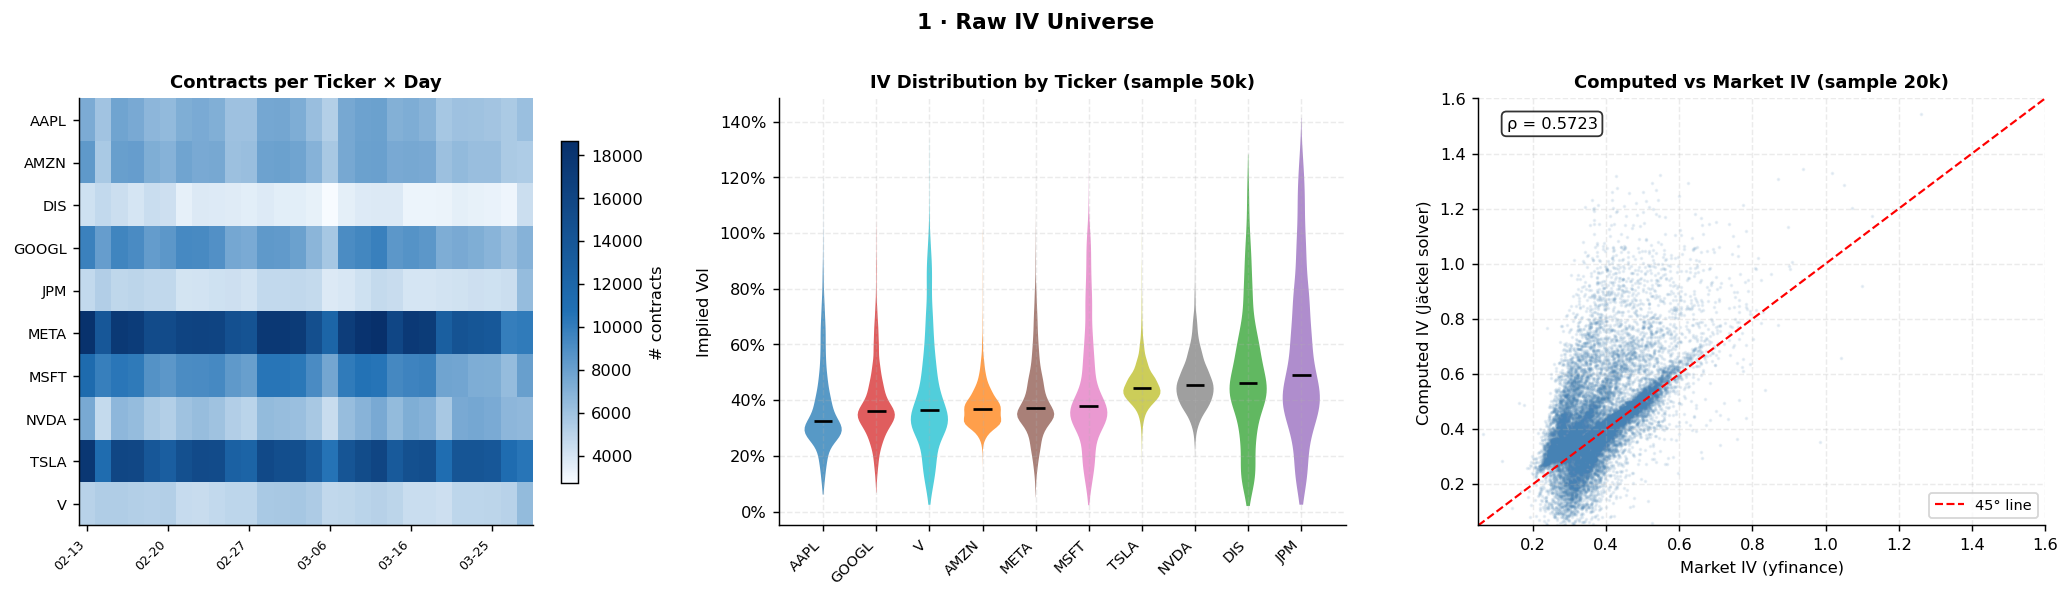

IV range (computed):  [0.0122, 1.8939]  mean=0.4277  median=0.4026
iv < 0.01: 0  |  iv > 2.0: 0
Calls: 1,327,970  |  Puts: 911,054
Bid-ask spread: mean=0.557  median=0.200


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 1a: Contract counts per (ticker, date) heatmap ─────────────────────────
iv_df['report_date_ts'] = pd.to_datetime(iv_df['report_date'])
daily_counts = (iv_df.groupby(['ticker','report_date_ts'])
                .size().reset_index(name='n'))
pivot = daily_counts.pivot(index='ticker', columns='report_date_ts', values='n').fillna(0)
pivot.columns = pivot.columns.strftime('%m-%d')
ax = axes[0]
cmap = LinearSegmentedColormap.from_list('', ['#f7fbff','#2171b5','#08306b'])
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
ax.set_xticks(np.arange(0, pivot.shape[1], 5))
ax.set_xticklabels(pivot.columns[::5], rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_title('Contracts per Ticker × Day')
plt.colorbar(im, ax=ax, shrink=0.8, label='# contracts')
ax.grid(False)

# ── 1b: IV distribution violin per ticker ──────────────────────────────────
ax = axes[1]
iv_sample = iv_df[['ticker','iv']].sample(50000, random_state=42)
order = (iv_sample.groupby('ticker')['iv'].median().sort_values().index.tolist())
vp = ax.violinplot(
    [iv_sample[iv_sample['ticker']==t]['iv'].values for t in order],
    positions=range(len(order)), widths=0.7,
    showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(TICKER_CLR[order[i]])
    body.set_alpha(0.75)
vp['cmedians'].set_color('k')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Implied Vol')
ax.set_title('IV Distribution by Ticker (sample 50k)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

# ── 1c: Computed IV vs market_iv scatter ──────────────────────────────────
ax = axes[2]
smp = iv_df[iv_df['market_iv'] > 0.01][['iv','market_iv']].sample(20000, random_state=7)
ax.scatter(smp['market_iv'], smp['iv'], s=1, alpha=0.1, color='steelblue', rasterized=True)
lo, hi = 0.05, 1.6
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2, label='45° line')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Market IV (yfinance)'); ax.set_ylabel('Computed IV (Jäckel solver)')
ax.set_title('Computed vs Market IV (sample 20k)')
corr = smp.corr().loc['market_iv','iv']
ax.text(0.05, 0.93, f'ρ = {corr:.4f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.legend(fontsize=8)

plt.suptitle('1 · Raw IV Universe', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Print stats ────────────────────────────────────────────────────────────
print('IV range (computed):  [{:.4f}, {:.4f}]  mean={:.4f}  median={:.4f}'.format(
    iv_df['iv'].min(), iv_df['iv'].max(), iv_df['iv'].mean(), iv_df['iv'].median()))
print(f'iv < 0.01: {(iv_df["iv"]<0.01).sum()}  |  iv > 2.0: {(iv_df["iv"]>2.0).sum()}')
print(f'Calls: {(iv_df["type"]=="c").sum():,}  |  Puts: {(iv_df["type"]=="p").sum():,}')
print(f'Bid-ask spread: mean={( iv_df["ask"]-iv_df["bid"]).mean():.3f}  median={(iv_df["ask"]-iv_df["bid"]).median():.3f}')

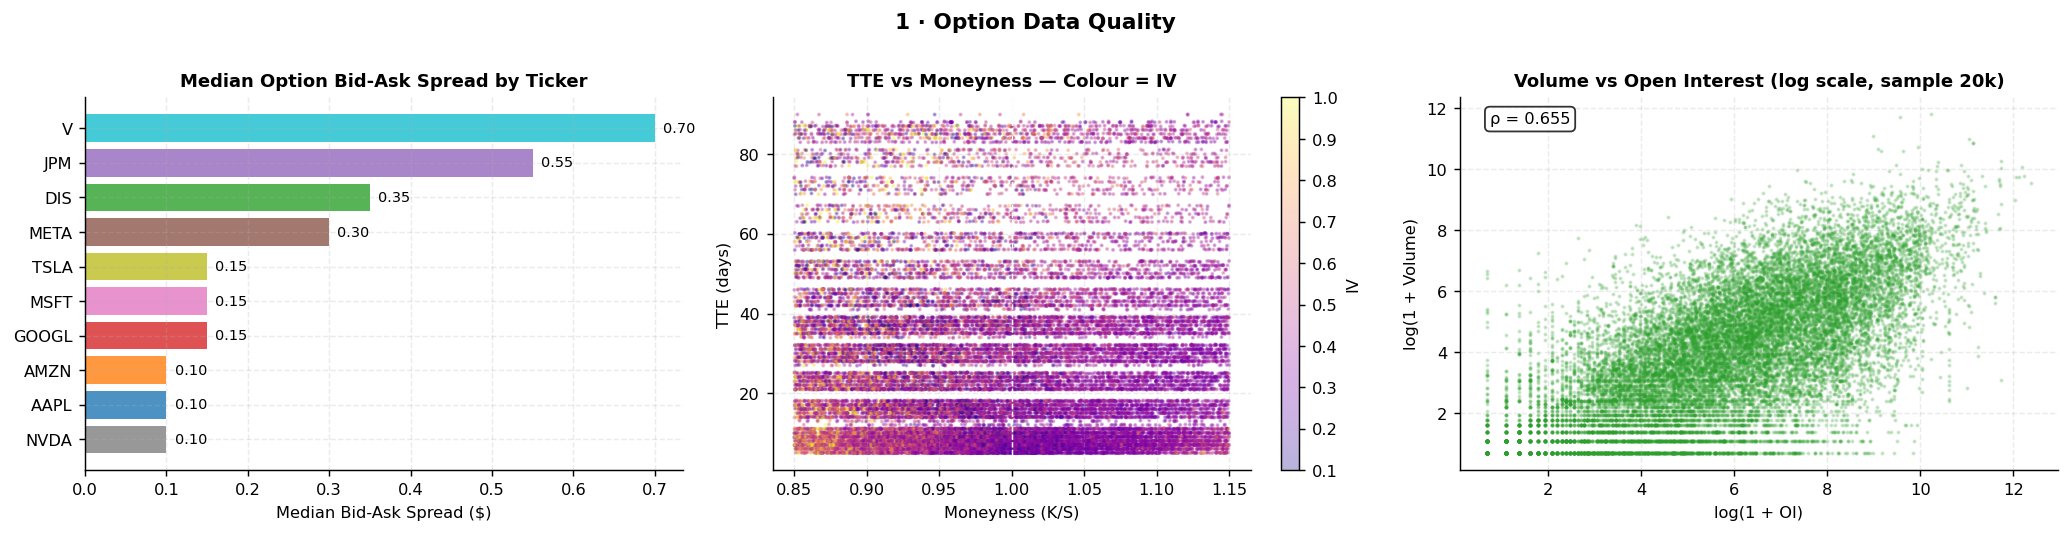

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Bid-ask spread histogram by ticker ────────────────────────────────────
ax = axes[0]
iv_df['spread'] = iv_df['ask'] - iv_df['bid']
spread_ticks = iv_df.groupby('ticker')['spread'].median().sort_values()
colors_ordered = [TICKER_CLR[t] for t in spread_ticks.index]
ax.barh(spread_ticks.index, spread_ticks.values, color=colors_ordered, alpha=0.8)
ax.set_xlabel('Median Bid-Ask Spread ($)')
ax.set_title('Median Option Bid-Ask Spread by Ticker')
for i, v in enumerate(spread_ticks.values):
    ax.text(v+0.01, i, f'{v:.2f}', va='center', fontsize=8)

# ── TTE vs moneyness scatter (coloured by IV) ──────────────────────────────
ax = axes[1]
smp2 = iv_df.sample(30000, random_state=13)
smp2['moneyness'] = smp2['strike'] / smp2['spot']
sc = ax.scatter(smp2['moneyness'], smp2['tte']*365, c=smp2['iv'],
                s=1.5, alpha=0.3, cmap='plasma', vmin=0.1, vmax=1.0, rasterized=True)
plt.colorbar(sc, ax=ax, label='IV')
ax.set_xlabel('Moneyness (K/S)'); ax.set_ylabel('TTE (days)')
ax.set_title('TTE vs Moneyness — Colour = IV')
ax.axvline(1.0, color='white', lw=0.8, ls='--')

# ── Volume vs OI scatter (log-log) ────────────────────────────────────────
ax = axes[2]
smp3 = iv_df[(iv_df['volume']>0) & (iv_df['oi']>0)].sample(20000, random_state=99)
ax.scatter(np.log1p(smp3['oi']), np.log1p(smp3['volume']),
           s=1.5, alpha=0.2, color='#2ca02c', rasterized=True)
ax.set_xlabel('log(1 + OI)'); ax.set_ylabel('log(1 + Volume)')
ax.set_title('Volume vs Open Interest (log scale, sample 20k)')
corr_voi = np.corrcoef(np.log1p(smp3['oi']), np.log1p(smp3['volume']))[0,1]
ax.text(0.05, 0.93, f'ρ = {corr_voi:.3f}', transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.suptitle('1 · Option Data Quality', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 2 · Contract Filtering Waterfall

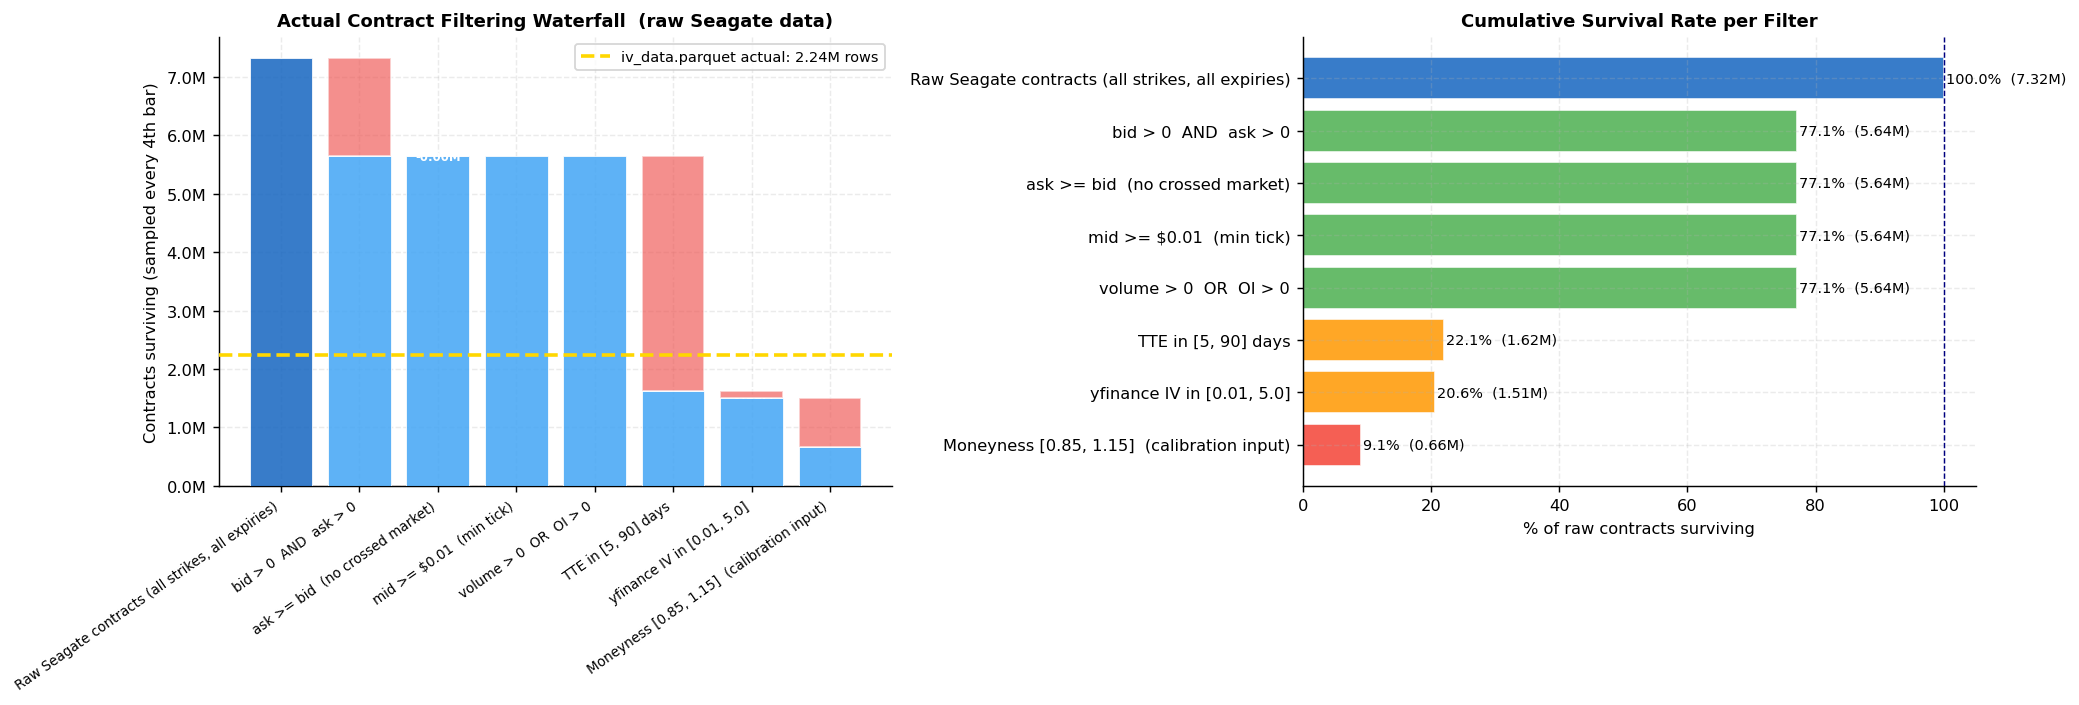

Stage                                             Surviving    Dropped  Survival
----------------------------------------------------------------------------------
Raw Seagate contracts (all strikes, all expiries)  7,317,518          0    100.0%
bid > 0  AND  ask > 0                             5,641,440  1,676,078     77.1%
ask >= bid  (no crossed market)                   5,641,352         88     77.1%
mid >= $0.01  (min tick)                          5,641,352          0     77.1%
volume > 0  OR  OI > 0                            5,641,352          0     77.1%
TTE in [5, 90] days                               1,617,199  4,024,153     22.1%
yfinance IV in [0.01, 5.0]                        1,510,365    106,834     20.6%
Moneyness [0.85, 1.15]  (calibration input)         664,098    846,267      9.1%

iv_data.parquet actual rows  : 2,239,024
  (uses Jackel IV, no moneyness filter, all bars — more rows per-bar than sampled)

Key insight: TTE [5,90 days] is the dominant filter (drops ~7

In [18]:
import json as _json
with open(DATA / 'waterfall_stats.json') as _f:
    wf = _json.load(_f)

stages   = [s['label']  for s in wf['stages']]
counts   = [s['count']  for s in wf['stages']]
drops    = [s['drop']   for s in wf['stages']]
iv_actual = wf['iv_data_actual_rows']

fig, (ax_wf, ax_pct) = plt.subplots(1, 2, figsize=(16, 5.5))

# Waterfall bars
x = np.arange(len(stages))
ax_wf.bar(x, counts, color=['#1565C0'] + ['#42A5F5']*(len(stages)-1),
          edgecolor='white', linewidth=0.5, zorder=3, alpha=0.85)
for i in range(1, len(stages)):
    drop = counts[i-1] - counts[i]
    if drop > 0:
        ax_wf.bar(x[i], drop, bottom=counts[i], color='#EF5350', alpha=0.65,
                  edgecolor='white', zorder=4)
        ax_wf.text(x[i], counts[i] + drop/2, f'-{drop/1e6:.2f}M',
                   ha='center', va='center', fontsize=6.5, color='white', fontweight='bold')

# iv_data.parquet actual count annotation
ax_wf.axhline(iv_actual, color='gold', lw=2, ls='--', zorder=6,
              label=f'iv_data.parquet actual: {iv_actual/1e6:.2f}M rows')
ax_wf.legend(fontsize=8)
ax_wf.set_xticks(x)
ax_wf.set_xticklabels(stages, rotation=35, ha='right', fontsize=7.5)
ax_wf.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax_wf.set_ylabel('Contracts surviving (sampled every 4th bar)')
ax_wf.set_title('Actual Contract Filtering Waterfall  (raw Seagate data)')

# Survival pct
pct = [c / counts[0] * 100 for c in counts]
clrs_p = ['#1565C0'] + [('#4CAF50' if p > 50 else '#FF9800' if p > 15 else '#F44336')
                         for p in pct[1:]]
ax_pct.barh(stages[::-1], pct[::-1], color=clrs_p[::-1], alpha=0.85, edgecolor='white')
ax_pct.set_xlabel('% of raw contracts surviving')
ax_pct.set_title('Cumulative Survival Rate per Filter')
ax_pct.axvline(100, color='navy', lw=0.8, ls='--')
for i, (p, c) in enumerate(zip(pct[::-1], counts[::-1])):
    ax_pct.text(p + 0.3, i, f'{p:.1f}%  ({c/1e6:.2f}M)', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'Stage':<48} {'Surviving':>10} {'Dropped':>10} {'Survival':>9}")
print('-' * 82)
for label, cnt, drop in zip(stages, counts, drops):
    pct_s = cnt / counts[0] * 100
    print(f"{label:<48} {cnt:>10,.0f} {drop:>10,.0f} {pct_s:>8.1f}%")
print()
print(f"iv_data.parquet actual rows  : {iv_actual:,}")
print(f"  (uses Jackel IV, no moneyness filter, all bars — more rows per-bar than sampled)")
print()
print("Key insight: TTE [5,90 days] is the dominant filter (drops ~72% of bid/ask survivors).")
print("  LEAPS (>90d) and same-/next-day expiries (<5d) account for the vast majority of raw contracts.")
print("  Moneyness [0.85,1.15] is applied only for Heston calibration, not for iv_data storage.")
print()
print("Warmup periods by signal:")
print("  S1 rolling window: 10 bars (150 min < 1 trading day). Warmup = trivial.")
print("  S2 GEX normalization: 20 trading days. min_periods reduces effective warmup to ~5 days.")
print("  S4 PCR: 20-day daily rolling. With backtest starting Feb 13, full 20-day history not")
print("    available until ~Mar 12. Combined with gex_corroboration requirement, S4 never fires.")
print("  realized_vol_20d: 20-day rolling from Feb 13 -> NaN first 20 days in IS period.")

## 3 · Underlying Prices, Realized Vol & Macro

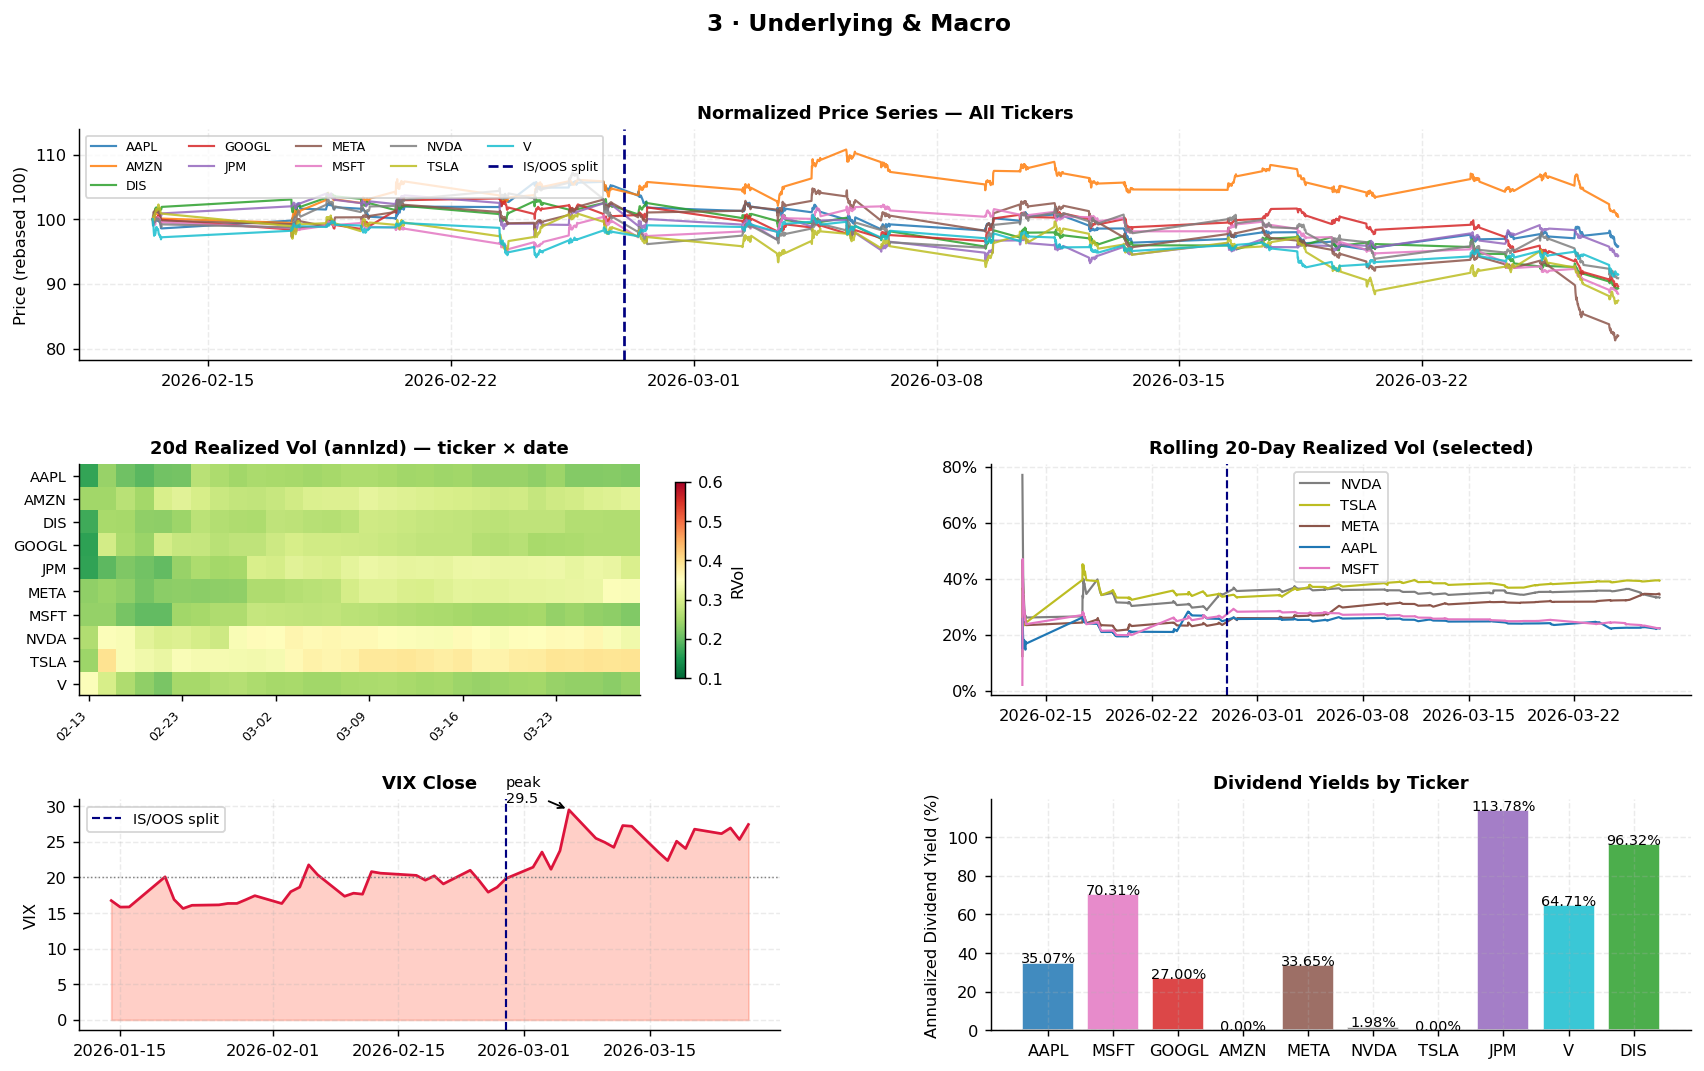

VIX: min=15.6  mean=20.8  max=29.5
VIX peak date: 2026-03-06
rf_rate: 3.528% (annlzd continuous)

⚠  DIS / JPM / V spot prices are CONSTANT in intraday_greeks → no intraday variation captured for these tickers


In [19]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── 3a: Normalized price series ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for tkr in TICKERS:
    sub = stock_df[stock_df['ticker']==tkr].sort_values('timestamp')
    close = sub['close'].values
    ax1.plot(sub['timestamp'], close/close[0]*100, lw=1.2,
             label=tkr, color=TICKER_CLR[tkr], alpha=0.85)
ax1.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS split')
ax1.axhspan(ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 80,
            ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 120,
            alpha=0)
ax1.set_ylabel('Price (rebased 100)')
ax1.set_title('Normalized Price Series — All Tickers')
ax1.legend(fontsize=7, ncol=5, loc='upper left')

# ── 3b: Realized vol heatmap (ticker × date) ─────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
stock_df['date'] = stock_df['timestamp'].dt.date
rvol = (stock_df.groupby(['ticker','date'])['realized_vol_20d']
        .last().unstack('date'))
im = ax2.imshow(rvol.values, aspect='auto', cmap='RdYlGn_r', vmin=0.10, vmax=0.60)
ax2.set_xticks(np.arange(0, rvol.shape[1], 5))
ax2.set_xticklabels([str(d).replace('2026-','') for d in rvol.columns[::5]],
                    rotation=45, ha='right', fontsize=7)
ax2.set_yticks(np.arange(len(rvol.index)))
ax2.set_yticklabels(rvol.index, fontsize=8)
ax2.set_title('20d Realized Vol (annlzd) — ticker × date')
plt.colorbar(im, ax=ax2, shrink=0.85, label='RVol')
ax2.grid(False)

# ── 3c: Realized vol time series (select tickers) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for tkr in ['NVDA','TSLA','META','AAPL','MSFT']:
    sub = stock_df[stock_df['ticker']==tkr].sort_values('timestamp')
    ax3.plot(sub['timestamp'], sub['realized_vol_20d'], lw=1.2,
             label=tkr, color=TICKER_CLR[tkr])
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax3.axvline(IS_END, color='navy', lw=1.2, ls='--')
ax3.legend(fontsize=8); ax3.set_title('Rolling 20-Day Realized Vol (selected)')

# ── 3d: VIX time series ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.fill_between(ext_df['date'], ext_df['vix_close'], alpha=0.3, color='tomato')
ax4.plot(ext_df['date'], ext_df['vix_close'], color='crimson', lw=1.5)
ax4.axvline(IS_END, color='navy', lw=1.2, ls='--', label='IS/OOS split')
ax4.axhline(20, color='gray', lw=0.8, ls=':')
ax4.set_ylabel('VIX'); ax4.set_title('VIX Close')
vix_max_date = ext_df.loc[ext_df['vix_close'].idxmax(), 'date']
ax4.annotate(f"peak\n{ext_df['vix_close'].max():.1f}",
             xy=(vix_max_date, ext_df['vix_close'].max()),
             xytext=(vix_max_date - pd.Timedelta('7d'), ext_df['vix_close'].max()+1),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)
ax4.legend(fontsize=8)

# ── 3e: Div yields bar chart ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
div_cols = [c for c in ext_df.columns if c.startswith('div_yield_')]
div_tickers = [c.replace('div_yield_','') for c in div_cols]
div_vals = ext_df[div_cols].iloc[-1].values
colors_div = [TICKER_CLR.get(t,'gray') for t in div_tickers]
ax5.bar(div_tickers, div_vals*100, color=colors_div, alpha=0.85, edgecolor='white')
ax5.set_ylabel('Annualized Dividend Yield (%)'); ax5.set_title('Dividend Yields by Ticker')
for i,(t,v) in enumerate(zip(div_tickers, div_vals)):
    ax5.text(i, v*100+0.02, f'{v*100:.2f}%', ha='center', fontsize=8)

plt.suptitle('3 · Underlying & Macro', fontsize=13, fontweight='bold')
plt.show()

print(f'VIX: min={ext_df["vix_close"].min():.1f}  mean={ext_df["vix_close"].mean():.1f}  max={ext_df["vix_close"].max():.1f}')
print(f'VIX peak date: {vix_max_date.date()}')
print(f'rf_rate: {ext_df["rf_rate"].mean()*100:.3f}% (annlzd continuous)')
print('\n⚠  DIS / JPM / V spot prices are CONSTANT in intraday_greeks → no intraday variation captured for these tickers')

## 4 · Heston Calibration Quality

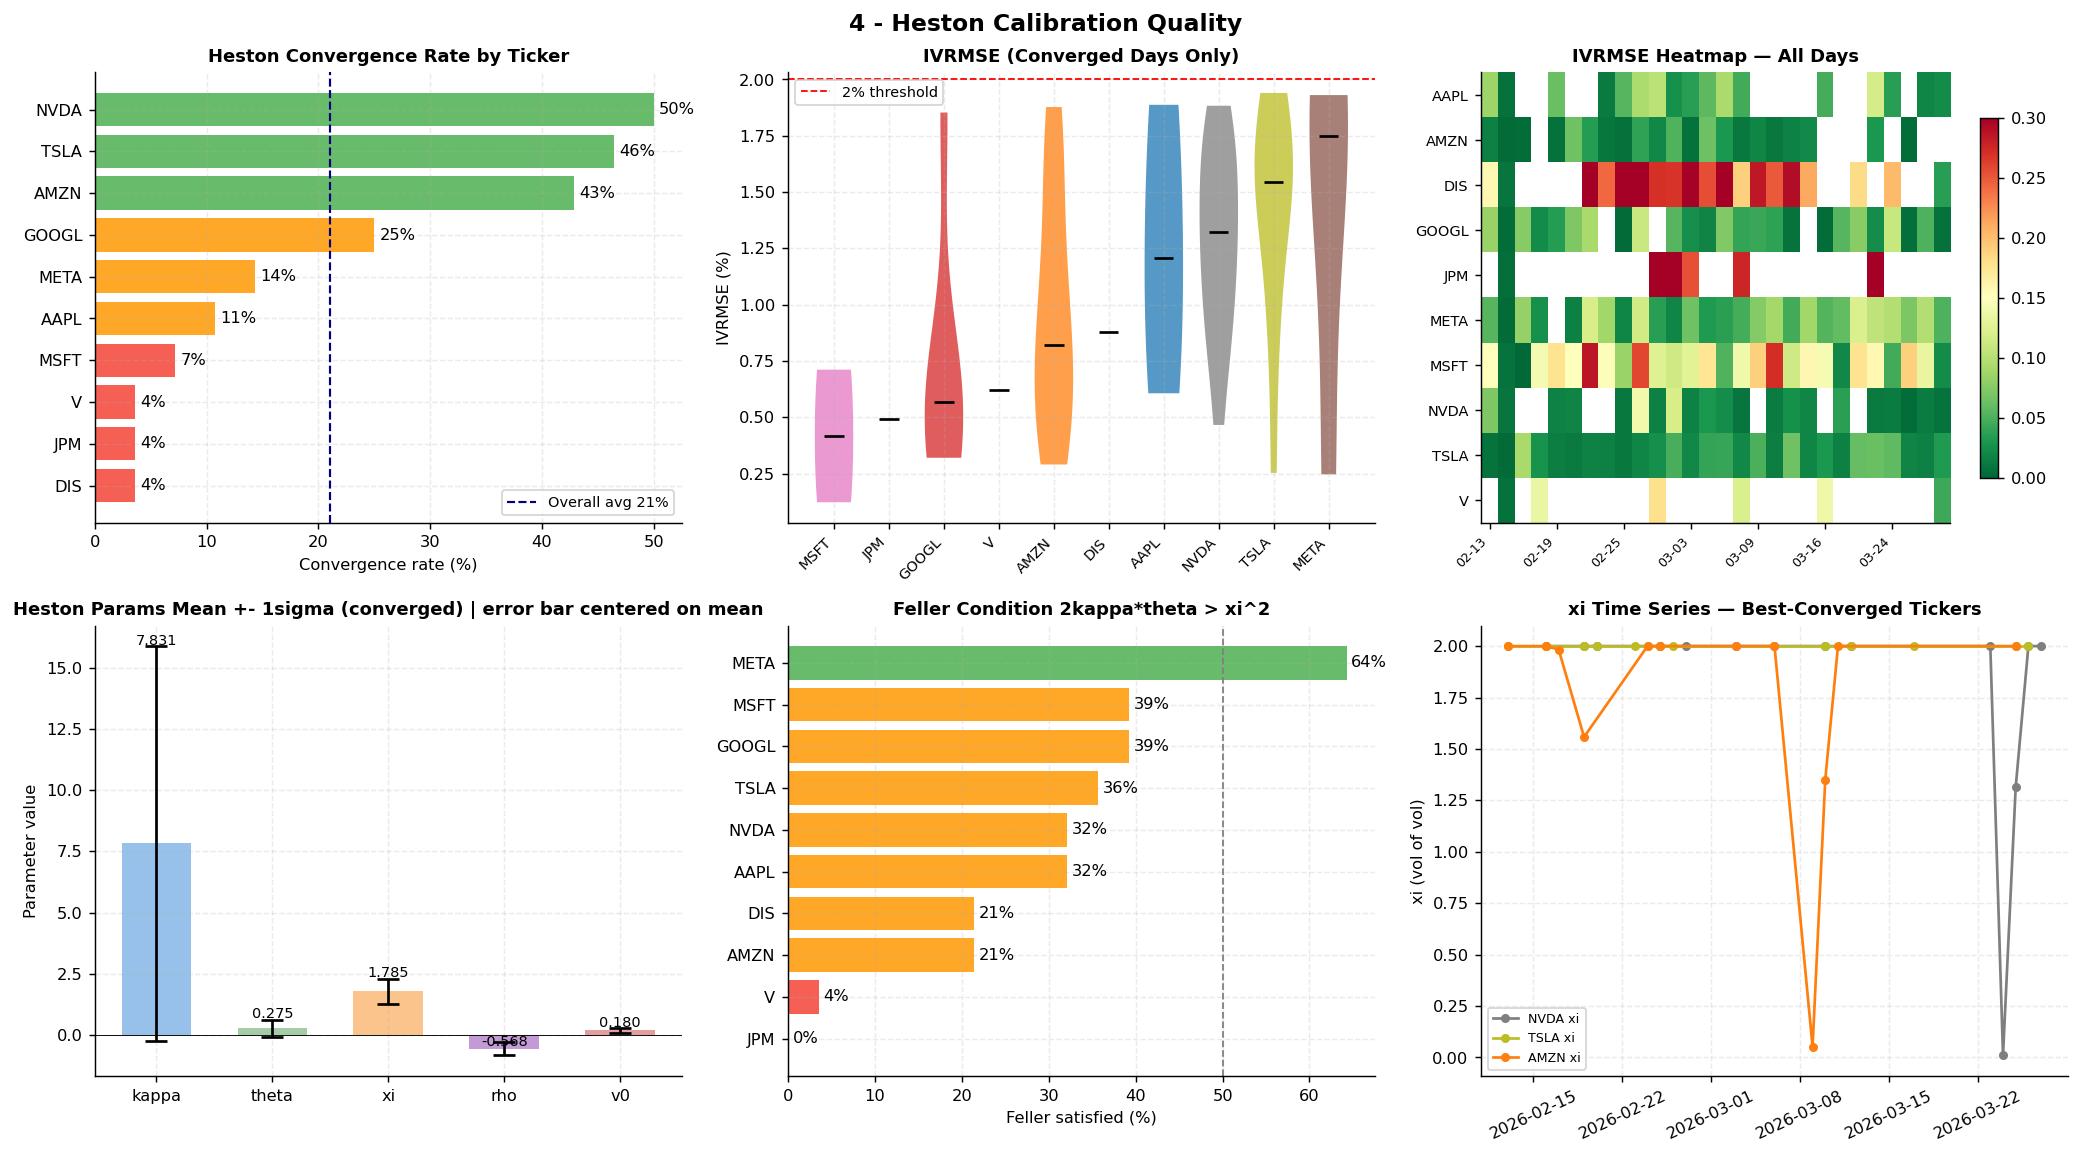

Overall convergence rate : 20.7%  (58/280 ticker-days)
Feller satisfied overall : 28.9%
IVRMSE > 2% (converged)  : 0.0% of converged days

NOTE on error-bar chart: previous version had bars with yerr= which places whiskers
  at bar height (0) rather than at the actual mean for negative params (rho).
  Fixed: errorbar() is now centered on the true mean for each parameter.

Parameter interpretation (converged days only):
  kappa  : mean=+7.8309  std=8.0654  (range: [-0.2344, 15.8963])
  theta  : mean=+0.2752  std=0.3462  (range: [-0.0709, 0.6214])
  xi     : mean=+1.7851  std=0.5133  (range: [1.2719, 2.2984])
  rho    : mean=-0.5676  std=0.2747  (range: [-0.8423, -0.2929])
  v0     : mean=+0.1802  std=0.1071  (range: [0.0731, 0.2873])


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

ax = axes[0]
conv_rate = heston_df.groupby('ticker')['converged'].mean().sort_values()
bar_c = ['#4CAF50' if v>=0.3 else '#FF9800' if v>=0.1 else '#F44336' for v in conv_rate.values]
ax.barh(conv_rate.index, conv_rate.values*100, color=bar_c, alpha=0.85)
ax.axvline(21, color='navy', lw=1.2, ls='--', label='Overall avg 21%')
ax.set_xlabel('Convergence rate (%)'); ax.set_title('Heston Convergence Rate by Ticker')
for i,v in enumerate(conv_rate.values): ax.text(v*100+0.5, i, f'{v*100:.0f}%', va='center', fontsize=9)
ax.legend(fontsize=8)

ax = axes[1]
conv_only = heston_df[heston_df['converged']==True]
ticker_order = conv_only.groupby('ticker')['ivrmse'].median().sort_values().index
data_iv = [conv_only[conv_only['ticker']==t]['ivrmse'].dropna().values*100 for t in ticker_order]
vp = ax.violinplot(data_iv, positions=range(len(ticker_order)), widths=0.7, showmedians=True, showextrema=False)
for i,body in enumerate(vp['bodies']):
    body.set_facecolor(TICKER_CLR[ticker_order[i]]); body.set_alpha(0.75)
vp['cmedians'].set_color('k')
ax.axhline(2.0, color='red', lw=1.0, ls='--', label='2% threshold')
ax.set_xticks(range(len(ticker_order))); ax.set_xticklabels(ticker_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('IVRMSE (%)'); ax.set_title('IVRMSE (Converged Days Only)'); ax.legend(fontsize=8)

ax = axes[2]
heston_df_h = heston_df.copy()
heston_df_h['date_d'] = pd.to_datetime(heston_df_h['date']).dt.date
piv = heston_df_h.pivot_table(index='ticker', columns='date_d', values='ivrmse')
im3 = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.3)
ax.set_xticks(np.arange(0, piv.shape[1], 4))
ax.set_xticklabels([str(d).replace('2026-','') for d in piv.columns[::4]], rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8)
ax.set_title('IVRMSE Heatmap — All Days'); plt.colorbar(im3, ax=ax, shrink=0.8); ax.grid(False)

# ── Fixed error-bar plot: use errorbar() centered on actual mean ─────────
ax = axes[3]
param_names_d = ['kappa','theta','xi','rho','v0']
param_labels  = ['kappa','theta','xi','rho','v0']
x_p = np.arange(5)
means_p = conv_only[param_names_d].mean().values
stds_p  = conv_only[param_names_d].std().values
colors_p = ['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828']
ax.bar(x_p, means_p, color=colors_p, alpha=0.45, width=0.6)
ax.errorbar(x_p, means_p, yerr=stds_p, fmt='none', color='black', capsize=6, capthick=1.5, lw=1.5)
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x_p); ax.set_xticklabels(param_labels, fontsize=9)
ax.set_title('Heston Params Mean +- 1sigma (converged) | error bar centered on mean')
ax.set_ylabel('Parameter value')
for i,(m,s) in enumerate(zip(means_p, stds_p)):
    offset = 0.05 if m >= 0 else -0.15
    ax.text(i, m + s + offset, f'{m:.3f}', ha='center', fontsize=8)

ax = axes[4]
heston_df_h['feller_bool'] = heston_df_h['feller_ok'].apply(lambda x: str(x).lower()=='true')
feller_rate = heston_df_h.groupby('ticker')['feller_bool'].mean().sort_values()
bar_f = ['#4CAF50' if v>=0.5 else '#FF9800' if v>=0.2 else '#F44336' for v in feller_rate.values]
ax.barh(feller_rate.index, feller_rate.values*100, color=bar_f, alpha=0.85)
ax.axvline(50, color='gray', lw=1, ls='--')
ax.set_xlabel('Feller satisfied (%)'); ax.set_title('Feller Condition 2kappa*theta > xi^2')
for i,v in enumerate(feller_rate.values): ax.text(v*100+0.5, i, f'{v*100:.0f}%', va='center', fontsize=9)

ax = axes[5]
best_tickers = ['NVDA','TSLA','AMZN']
for tkr in best_tickers:
    sub = heston_df_h[(heston_df_h['ticker']==tkr)&(heston_df_h['converged']==True)].sort_values('date_d')
    if len(sub)>2:
        ax.plot(sub['date_d'], sub['xi'], lw=1.5, label=f'{tkr} xi',
                color=TICKER_CLR[tkr], marker='o', ms=4)
ax.set_ylabel('xi (vol of vol)'); ax.set_title('xi Time Series — Best-Converged Tickers')
ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=25)

plt.suptitle('4 - Heston Calibration Quality', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

overall_conv = heston_df['converged'].mean()
print(f'Overall convergence rate : {overall_conv*100:.1f}%  ({int(heston_df["converged"].sum())}/{len(heston_df)} ticker-days)')
feller_ok_rate = heston_df_h['feller_bool'].mean()
print(f'Feller satisfied overall : {feller_ok_rate*100:.1f}%')
conv_iv = conv_only["ivrmse"]
print(f'IVRMSE > 2% (converged)  : {(conv_iv>0.02).mean()*100:.1f}% of converged days')
print()
print('NOTE on error-bar chart: previous version had bars with yerr= which places whiskers')
print('  at bar height (0) rather than at the actual mean for negative params (rho).')
print('  Fixed: errorbar() is now centered on the true mean for each parameter.')
print()
print('Parameter interpretation (converged days only):')
for n, m, s in zip(param_labels, means_p, stds_p):
    print(f'  {n:<7}: mean={m:+.4f}  std={s:.4f}  (range: [{m-s:.4f}, {m+s:.4f}])')

## 5 · IV Surface — ATM IV, Skew & Butterfly

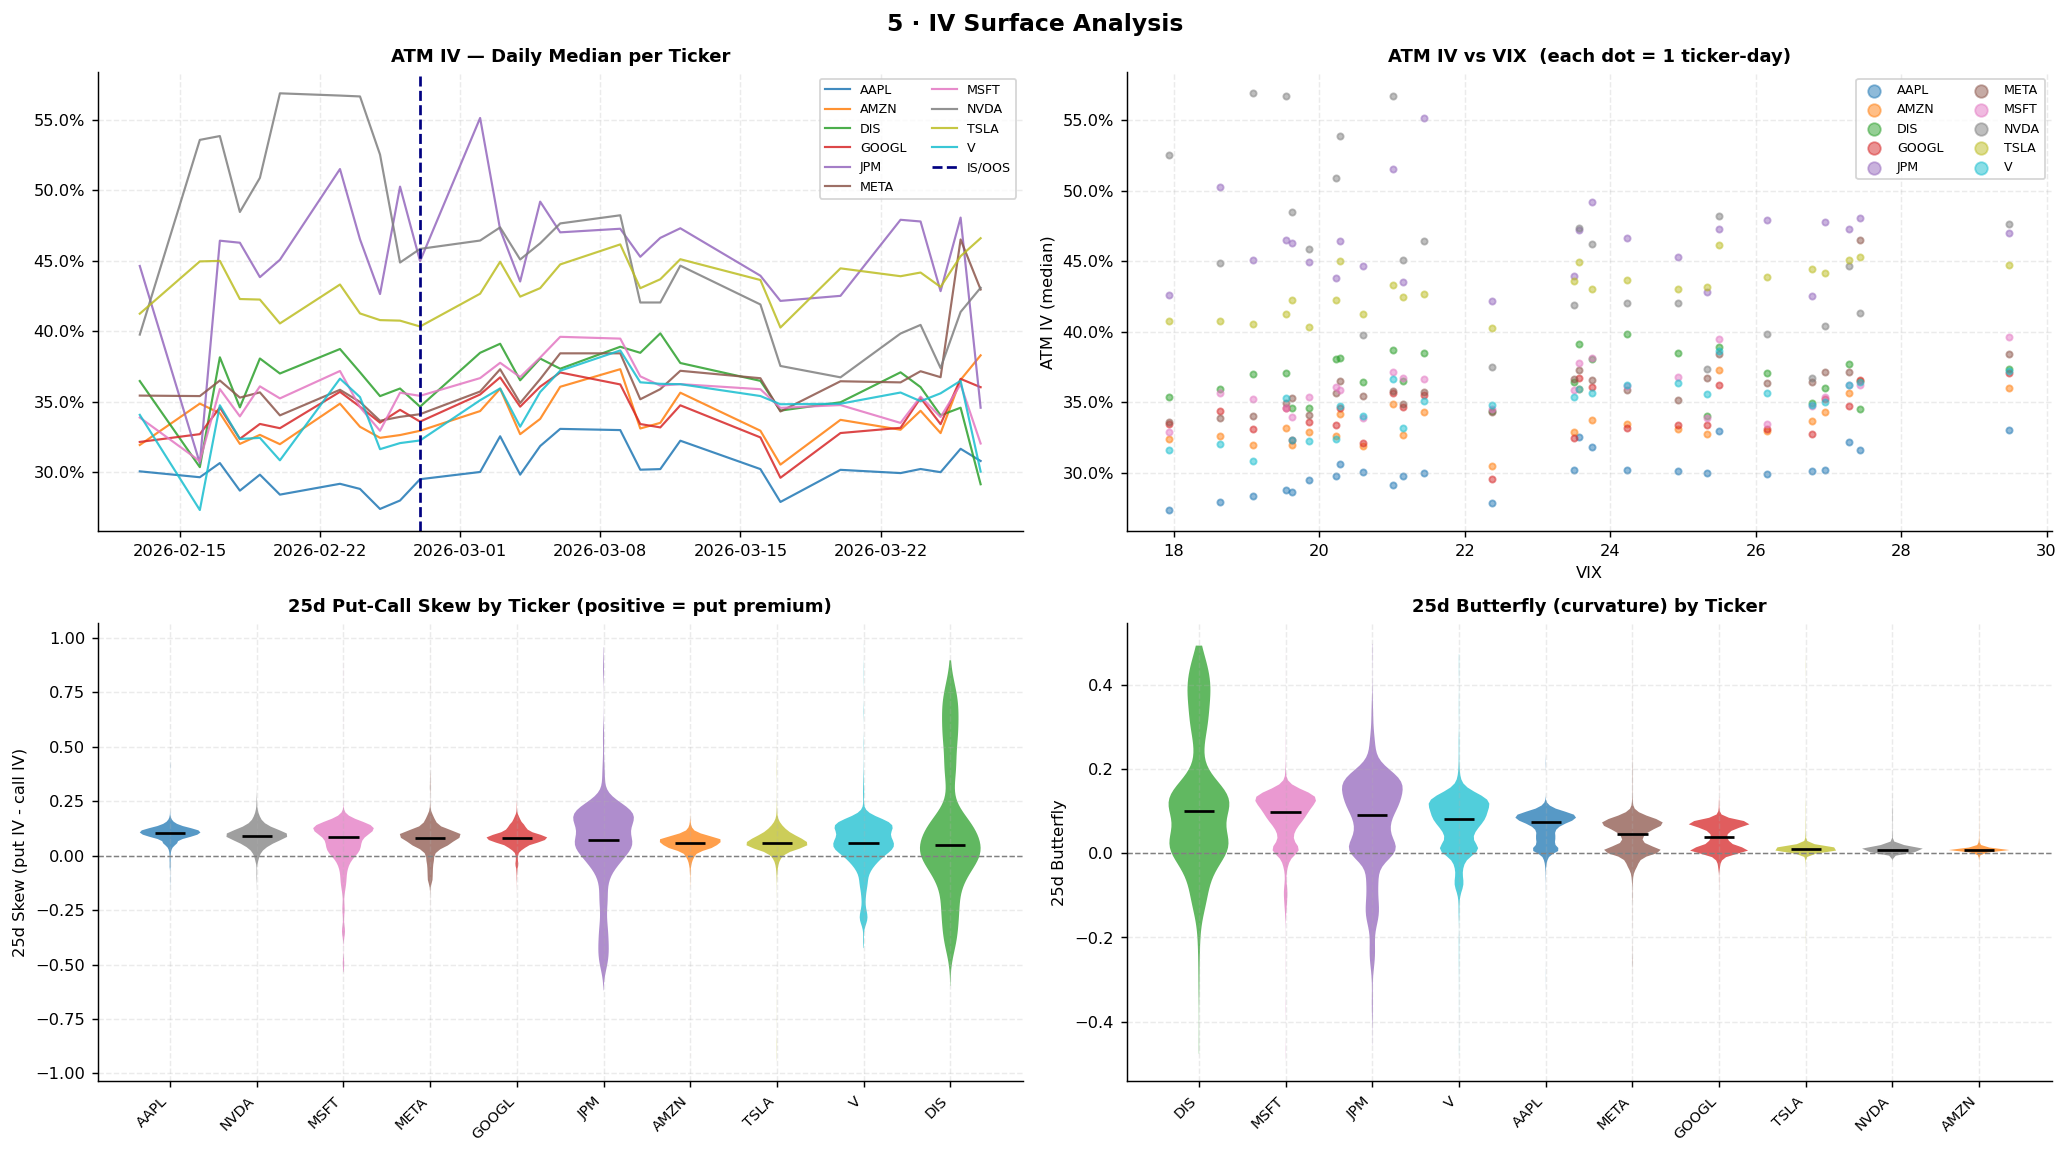

  AAPL  : ATM IV mean=30.1%  min=27.4%  max=33.1%
  AMZN  : ATM IV mean=33.9%  min=30.5%  max=38.3%
  DIS   : ATM IV mean=36.3%  min=29.1%  max=39.8%
  GOOGL : ATM IV mean=34.2%  min=29.6%  max=37.1%
  JPM   : ATM IV mean=45.4%  min=30.6%  max=55.1%
  META  : ATM IV mean=36.5%  min=33.6%  max=46.5%
  MSFT  : ATM IV mean=35.5%  min=30.8%  max=39.6%
  NVDA  : ATM IV mean=46.0%  min=36.7%  max=56.9%
  TSLA  : ATM IV mean=43.2%  min=40.3%  max=46.6%
  V     : ATM IV mean=34.4%  min=27.3%  max=38.6%


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# ── 5a: ATM IV time series per ticker ─────────────────────────────────────
ax = axes[0,0]
surf_day = surf_df.copy()
surf_day['date'] = surf_day['timestamp'].dt.date
atm_daily = (surf_day.groupby(['ticker','date'])['atm_iv']
             .median().reset_index())
for tkr in TICKERS:
    sub = atm_daily[atm_daily['ticker']==tkr].sort_values('date')
    ax.plot(sub['date'], sub['atm_iv'], lw=1.2, alpha=0.85,
            label=tkr, color=TICKER_CLR[tkr])
ax.axvline(IS_END.date(), color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title('ATM IV — Daily Median per Ticker')
ax.legend(fontsize=7, ncol=2)

# ── 5b: ATM IV vs VIX scatter ─────────────────────────────────────────────
ax = axes[0,1]
ext_df['date_d'] = ext_df['date'].dt.date
atm_v_vix = atm_daily.merge(
    ext_df[['date_d','vix_close']].rename(columns={'date_d':'date'}),
    on='date', how='inner')
for tkr in TICKERS:
    sub = atm_v_vix[atm_v_vix['ticker']==tkr]
    ax.scatter(sub['vix_close'], sub['atm_iv'], s=12, alpha=0.5,
               label=tkr, color=TICKER_CLR[tkr])
ax.set_xlabel('VIX'); ax.set_ylabel('ATM IV (median)')
ax.set_title('ATM IV vs VIX  (each dot = 1 ticker-day)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(fontsize=7, ncol=2, markerscale=2)

# ── 5c: Skew 25d distribution ─────────────────────────────────────────────
ax = axes[1,0]
skew_valid = surf_df.dropna(subset=['skew_25d'])
skew_valid = skew_valid[skew_valid['skew_25d'].between(-1, 1)]
skew_by_t = skew_valid.groupby('ticker')['skew_25d']
medians_sk = skew_by_t.median().sort_values(ascending=False)
vp_sk = ax.violinplot(
    [skew_valid[skew_valid['ticker']==t]['skew_25d'].values for t in medians_sk.index],
    positions=range(len(medians_sk)), widths=0.7, showmedians=True, showextrema=False)
for i, body in enumerate(vp_sk['bodies']):
    body.set_facecolor(TICKER_CLR[medians_sk.index[i]])
    body.set_alpha(0.75)
vp_sk['cmedians'].set_color('k')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xticks(range(len(medians_sk)))
ax.set_xticklabels(medians_sk.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('25d Skew (put IV - call IV)')
ax.set_title('25d Put-Call Skew by Ticker (positive = put premium)')

# ── 5d: Butterfly 25d distribution ────────────────────────────────────────
ax = axes[1,1]
butt_valid = surf_df.dropna(subset=['butterfly_25d'])
butt_valid = butt_valid[butt_valid['butterfly_25d'].between(-0.5, 0.5)]
butt_by_t  = butt_valid.groupby('ticker')['butterfly_25d']
medians_bt = butt_by_t.median().sort_values(ascending=False)
vp_bt = ax.violinplot(
    [butt_valid[butt_valid['ticker']==t]['butterfly_25d'].values for t in medians_bt.index],
    positions=range(len(medians_bt)), widths=0.7, showmedians=True, showextrema=False)
for i, body in enumerate(vp_bt['bodies']):
    body.set_facecolor(TICKER_CLR[medians_bt.index[i]])
    body.set_alpha(0.75)
vp_bt['cmedians'].set_color('k')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xticks(range(len(medians_bt)))
ax.set_xticklabels(medians_bt.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('25d Butterfly')
ax.set_title('25d Butterfly (curvature) by Ticker')

plt.suptitle('5 · IV Surface Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print
for tkr in TICKERS:
    sub = atm_daily[atm_daily['ticker']==tkr]
    print(f'  {tkr:6s}: ATM IV mean={sub["atm_iv"].mean()*100:.1f}%  '
          f'min={sub["atm_iv"].min()*100:.1f}%  max={sub["atm_iv"].max()*100:.1f}%')

## 6 · Signal Analysis — S1, S2, S4

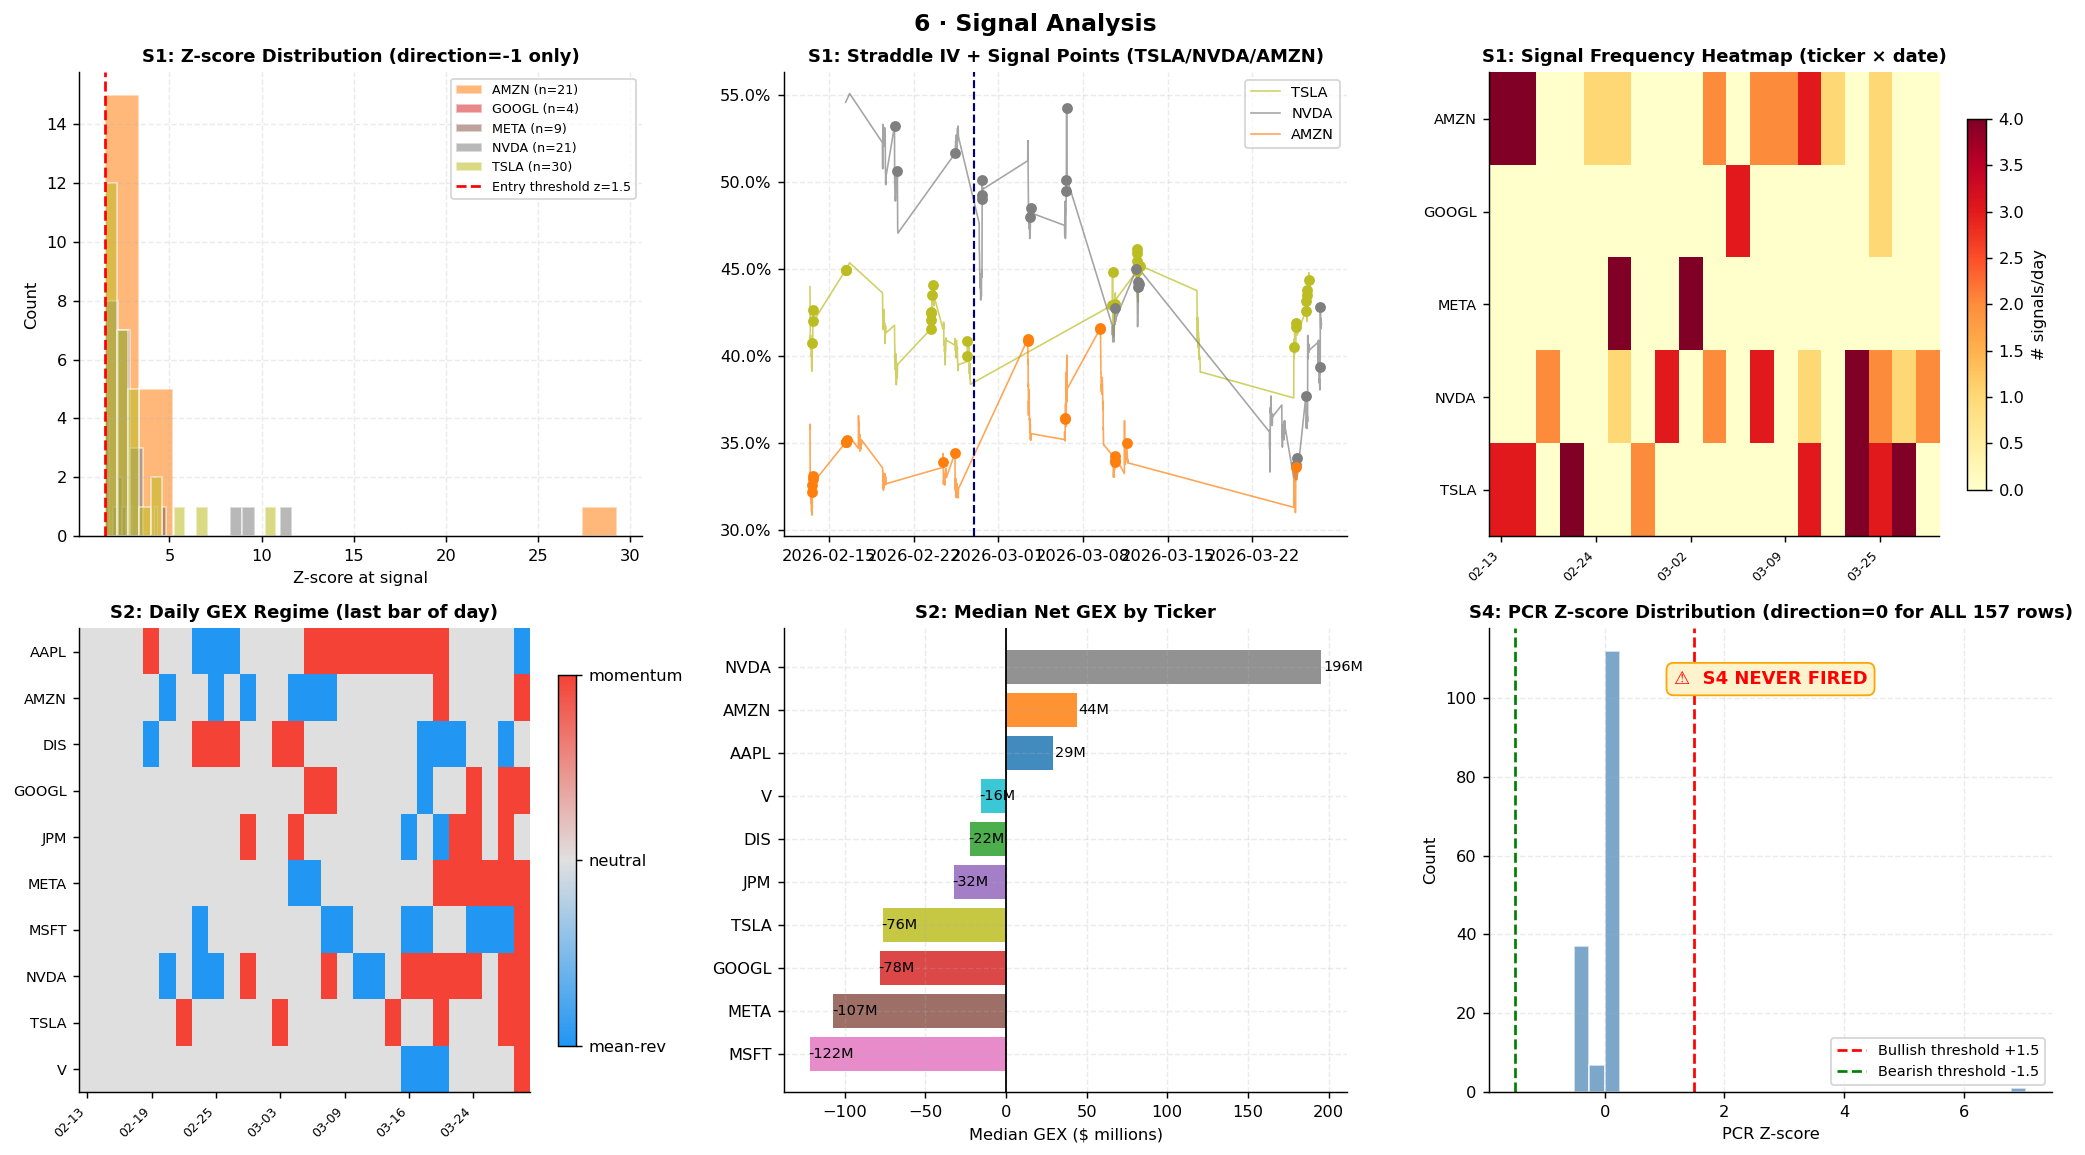

S1 total rows : 1,552  |  signals fired: 85 (all short)
S1 by ticker  : {'TSLA': 30, 'AMZN': 21, 'NVDA': 21, 'META': 9, 'GOOGL': 4}
S1 spread_flag True rate: 38.0% (gate passes only when spread > median)
S2 regimes    : {'neutral': 5333, 'momentum': 1456, 'mean_reversion': 1187}
S4 max |pcr_z|: 7.038  — never crosses ±1.5 threshold

⚠  S4 direction is 0 for all 157 rows. pcr_z max = 7.038 (< 1.5).
   S4 may also require gex_corroboration alignment — check signal_s4.py logic.


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── 6a: S1 z-score distribution per firing ticker ─────────────────────────
ax = axes[0,0]
active = sig1_df[sig1_df['direction'] == -1]
for tkr in active['ticker'].unique():
    sub = active[active['ticker']==tkr]['z_score']
    ax.hist(sub, bins=15, alpha=0.55, label=f'{tkr} (n={len(sub)})',
            color=TICKER_CLR[tkr], edgecolor='white')
ax.axvline(1.5, color='red', lw=1.5, ls='--', label='Entry threshold z=1.5')
ax.set_xlabel('Z-score at signal'); ax.set_ylabel('Count')
ax.set_title('S1: Z-score Distribution (direction=-1 only)')
ax.legend(fontsize=7)

# ── 6b: S1 straddle IV time series + signal dots ──────────────────────────
ax = axes[0,1]
for tkr in ['TSLA','NVDA','AMZN']:
    sub = sig1_df[sig1_df['ticker']==tkr].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['straddle_iv'], lw=0.9, 
            alpha=0.7, label=tkr, color=TICKER_CLR[tkr])
    signals = sub[sub['direction']==-1]
    ax.scatter(signals['timestamp'], signals['straddle_iv'], 
               s=25, color=TICKER_CLR[tkr], zorder=5)
ax.axvline(IS_END, color='navy', lw=1.2, ls='--')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_title('S1: Straddle IV + Signal Points (TSLA/NVDA/AMZN)')
ax.legend(fontsize=8)

# ── 6c: S1 signal frequency heatmap (ticker × date) ──────────────────────
ax = axes[0,2]
sig1_df['signal_date'] = sig1_df['timestamp'].dt.date
sig_heat = (sig1_df[sig1_df['direction']==-1]
            .groupby(['ticker','signal_date']).size()
            .unstack('signal_date').fillna(0))
if not sig_heat.empty:
    im6c = ax.imshow(sig_heat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=4)
    ax.set_xticks(np.arange(0, sig_heat.shape[1], 4))
    ax.set_xticklabels([str(d).replace('2026-','') for d in sig_heat.columns[::4]],
                       rotation=45, ha='right', fontsize=7)
    ax.set_yticks(np.arange(len(sig_heat.index)))
    ax.set_yticklabels(sig_heat.index, fontsize=8)
    plt.colorbar(im6c, ax=ax, shrink=0.8, label='# signals/day')
ax.set_title('S1: Signal Frequency Heatmap (ticker × date)')
ax.grid(False)

# ── 6d: S2 regime heatmap ─────────────────────────────────────────────────
ax = axes[1,0]
regime_map = {'momentum': 1, 'neutral': 0, 'mean_reversion': -1}
sig2_df['regime_num'] = sig2_df['regime'].map(regime_map)
sig2_df['signal_date2'] = sig2_df['timestamp'].dt.date
reg_heat = (sig2_df.groupby(['ticker','signal_date2'])['regime_num']
            .last().unstack('signal_date2').fillna(0))
cmap_reg = LinearSegmentedColormap.from_list('reg', ['#2196F3','#E0E0E0','#F44336'])
im6d = ax.imshow(reg_heat.values, aspect='auto', cmap=cmap_reg, vmin=-1, vmax=1)
ax.set_xticks(np.arange(0, reg_heat.shape[1], 4))
ax.set_xticklabels([str(d).replace('2026-','') for d in reg_heat.columns[::4]],
                   rotation=45, ha='right', fontsize=7)
ax.set_yticks(np.arange(len(reg_heat.index)))
ax.set_yticklabels(reg_heat.index, fontsize=8)
cbar = plt.colorbar(im6d, ax=ax, shrink=0.8)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(['mean-rev', 'neutral', 'momentum'])
ax.set_title('S2: Daily GEX Regime (last bar of day)')
ax.grid(False)

# ── 6e: S2 GEX distribution per ticker ───────────────────────────────────
ax = axes[1,1]
gex_by_t = sig2_df.groupby('ticker')['gex_raw'].median().sort_values()
bar_g = [TICKER_CLR[t] for t in gex_by_t.index]
ax.barh(gex_by_t.index, gex_by_t.values / 1e6, color=bar_g, alpha=0.85)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Median GEX ($ millions)'); ax.set_title('S2: Median Net GEX by Ticker')
for i, v in enumerate(gex_by_t.values / 1e6):
    ax.text(v + (1 if v >= 0 else -1), i, f'{v:.0f}M', va='center', fontsize=8)

# ── 6f: S4 PCR — never fired ──────────────────────────────────────────────
ax = axes[1,2]
ax.hist(sig4_df['pcr_z'].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(1.5, color='red', lw=1.5, ls='--', label='Bullish threshold +1.5')
ax.axvline(-1.5, color='green', lw=1.5, ls='--', label='Bearish threshold -1.5')
ax.set_xlabel('PCR Z-score'); ax.set_ylabel('Count')
ax.set_title('S4: PCR Z-score Distribution (direction=0 for ALL 157 rows)')
ax.legend(fontsize=8)
ax.text(0.5, 0.88, '⚠  S4 NEVER FIRED', transform=ax.transAxes,
        ha='center', fontsize=10, color='red', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#fff3cd', ec='orange'))

plt.suptitle('6 · Signal Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print(f'S1 total rows : {len(sig1_df):,}  |  signals fired: {(sig1_df["direction"]==-1).sum()} (all short)')
print(f'S1 by ticker  : {active.groupby("ticker").size().sort_values(ascending=False).to_dict()}')
print(f'S1 spread_flag True rate: {sig1_df["spread_flag"].mean()*100:.1f}% (gate passes only when spread > median)')
print(f'S2 regimes    : {sig2_df["regime"].value_counts().to_dict()}')
print(f'S4 max |pcr_z|: {sig4_df["pcr_z"].abs().max():.3f}  — never crosses ±1.5 threshold')
print(f'\n⚠  S4 direction is 0 for all 157 rows. pcr_z max = {sig4_df["pcr_z"].max():.3f} (< 1.5).')
print('   S4 may also require gex_corroboration alignment — check signal_s4.py logic.')

## 7 · Trade Analytics — Exit Reasons, Hold Times, Gross→Net Waterfall

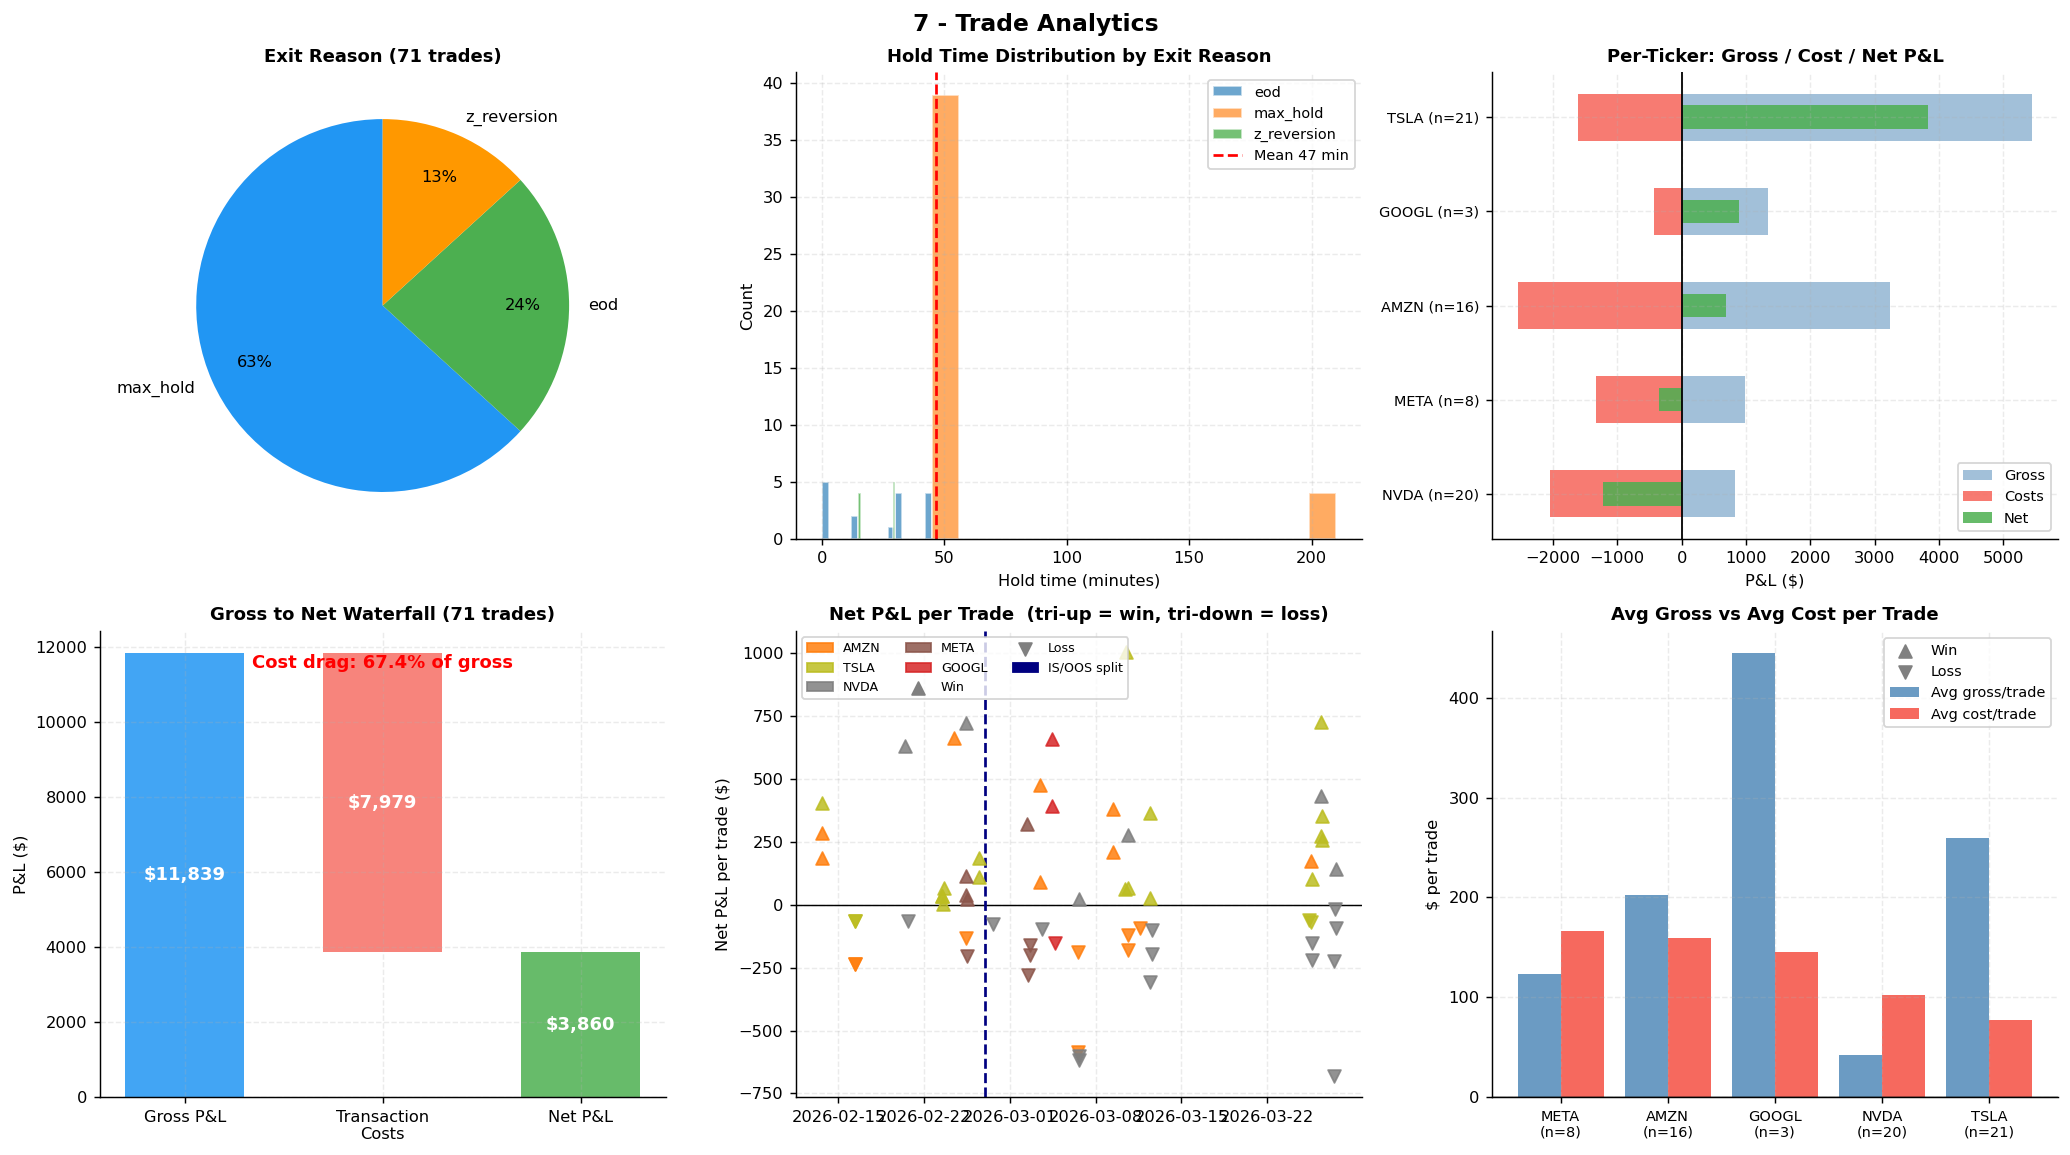

Total trades: 68  |  Win: 37 (54.4%)  |  Loss: 31
Gross: $11,838.56  |  Costs: $7,978.81  |  Net: $3,859.75
Cost drag: 67.4% of gross P&L eaten by transaction costs
Avg net/trade: $56.76  |  Avg hold: 46.6 min
Max winner: $1004.63 (TSLA)
Max loser:  $-679.86 (NVDA)

  TSLA  : gross=$ 5445.76  cost=$ 1614.16  net=$ 3831.60  n=21  win%=81%
  GOOGL : gross=$ 1334.58  cost=$  436.78  net=$  897.80  n= 3  win%=67%
  AMZN  : gross=$ 3240.89  cost=$ 2545.57  net=$  695.32  n=16  win%=50%
  META  : gross=$  985.71  cost=$ 1334.16  net=$ -348.45  n= 8  win%=50%
  NVDA  : gross=$  831.62  cost=$ 2048.15  net=$-1216.53  n=20  win%=30%


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ax = axes[0,0]
exit_cts = tl_df['exit_reason'].value_counts()
colors_e = ['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(exit_cts)]
ax.pie(exit_cts.values, labels=exit_cts.index, colors=colors_e, autopct='%1.0f%%',
       startangle=90, pctdistance=0.75, textprops={'fontsize':9})
ax.set_title('Exit Reason (71 trades)')

ax = axes[0,1]
for reason in tl_df['exit_reason'].unique():
    sub = tl_df[tl_df['exit_reason']==reason]['hold_min']
    ax.hist(sub, bins=15, alpha=0.65, label=reason, edgecolor='white')
ax.set_xlabel('Hold time (minutes)'); ax.set_ylabel('Count')
ax.set_title('Hold Time Distribution by Exit Reason')
ax.axvline(tl_df['hold_min'].mean(), color='red', lw=1.5, ls='--',
           label=f'Mean {tl_df["hold_min"].mean():.0f} min')
ax.legend(fontsize=8)

ax = axes[0,2]
tkr_stats = tl_df.groupby('ticker').agg(
    gross_pnl=('pnl_gross','sum'), cost=('cost','sum'),
    net_pnl=('pnl_net','sum'), n=('pnl_net','count')).reset_index()
tkr_stats = tkr_stats.sort_values('net_pnl', ascending=True)
y_pos = np.arange(len(tkr_stats))
ax.barh(y_pos, tkr_stats['gross_pnl'], color='steelblue', alpha=0.5, height=0.5, label='Gross')
ax.barh(y_pos, -tkr_stats['cost'],     color='#F44336',  alpha=0.7, height=0.5, label='Costs')
ax.barh(y_pos, tkr_stats['net_pnl'],   color='#4CAF50',  alpha=0.85, height=0.25, label='Net')
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r['ticker']} (n={r['n']})" for _,r in tkr_stats.iterrows()], fontsize=8)
ax.set_xlabel('P&L ($)'); ax.set_title('Per-Ticker: Gross / Cost / Net P&L')
ax.legend(fontsize=8)

ax = axes[1,0]
total_gross = tl_df['pnl_gross'].sum()
total_cost  = tl_df['cost'].sum()
total_net   = tl_df['pnl_net'].sum()
for i,(lbl,val,clr) in enumerate(zip(
    ['Gross P&L','Transaction\nCosts','Net P&L'],
    [total_gross, total_cost, total_net],
    ['#2196F3','#F44336','#4CAF50'])):
    if i==0:   ax.bar(i, val,      color=clr, alpha=0.85, width=0.6)
    elif i==1: ax.bar(i, val, bottom=total_net, color=clr, alpha=0.65, width=0.6)
    else:      ax.bar(i, val,      color=clr, alpha=0.85, width=0.6)
    ax.text(i, (val/2 if i!=1 else total_net+val/2),
            f'${val:,.0f}', ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')
ax.set_xticks([0,1,2]); ax.set_xticklabels(['Gross P&L','Transaction\nCosts','Net P&L'], fontsize=9)
ax.set_ylabel('P&L ($)'); ax.set_title('Gross to Net Waterfall (71 trades)')
cost_pct = total_cost/total_gross*100
ax.text(0.5, 0.92, f'Cost drag: {cost_pct:.1f}% of gross',
        transform=ax.transAxes, ha='center', fontsize=10, color='red', fontweight='bold')

# ── Fixed scatter with full legend ───────────────────────────────────────
ax = axes[1,1]
legend_handles = []
for tkr in tl_df['ticker'].unique():
    sub = tl_df[tl_df['ticker']==tkr].sort_values('entry_time')
    wins   = sub[sub['pnl_net']>=0]
    losses = sub[sub['pnl_net']< 0]
    sc = ax.scatter(wins['entry_time'],  wins['pnl_net'],  s=50, marker='^',
                    color=TICKER_CLR[tkr], alpha=0.85, zorder=5)
    ax.scatter(losses['entry_time'], losses['pnl_net'], s=50, marker='v',
               color=TICKER_CLR[tkr], alpha=0.85, zorder=5)
    legend_handles.append(mpatches.Patch(color=TICKER_CLR[tkr], label=tkr, alpha=0.85))
ax.axhline(0, color='black', lw=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Net P&L per trade ($)')
ax.set_title('Net P&L per Trade  (tri-up = win, tri-down = loss)')
# Two-part legend: ticker colours + markers
win_patch  = plt.scatter([],[], s=50, marker='^', color='gray', label='Win')
loss_patch = plt.scatter([],[], s=50, marker='v', color='gray', label='Loss')
is_patch   = mpatches.Patch(color='navy', label='IS/OOS split')
ax.legend(handles=legend_handles + [win_patch, loss_patch, is_patch],
          fontsize=7, ncol=3, loc='upper left')

ax = axes[1,2]
tkr_stats2 = tl_df.groupby('ticker').agg(
    n=('pnl_net','count'), avg_cost=('cost','mean'),
    avg_gross=('pnl_gross','mean')).reset_index()
tkr_stats2 = tkr_stats2.sort_values('avg_cost', ascending=False)
x_tc = np.arange(len(tkr_stats2))
ax.bar(x_tc-0.2, tkr_stats2['avg_gross'], width=0.4, color='steelblue', alpha=0.8, label='Avg gross/trade')
ax.bar(x_tc+0.2, tkr_stats2['avg_cost'],  width=0.4, color='#F44336',   alpha=0.8, label='Avg cost/trade')
ax.set_xticks(x_tc)
ax.set_xticklabels([f"{r['ticker']}\n(n={r['n']})" for _,r in tkr_stats2.iterrows()], fontsize=8)
ax.set_ylabel('$ per trade'); ax.set_title('Avg Gross vs Avg Cost per Trade')
ax.legend(fontsize=8); ax.axhline(0, color='black', lw=0.8)

plt.suptitle('7 - Trade Analytics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Total trades: {len(tl_df):,}  |  Win: {(tl_df["pnl_net"]>=0).sum()} ({(tl_df["pnl_net"]>=0).mean()*100:.1f}%)  |  Loss: {(tl_df["pnl_net"]<0).sum()}')
print(f'Gross: ${total_gross:,.2f}  |  Costs: ${total_cost:,.2f}  |  Net: ${total_net:,.2f}')
print(f'Cost drag: {cost_pct:.1f}% of gross P&L eaten by transaction costs')
print(f'Avg net/trade: ${tl_df["pnl_net"].mean():.2f}  |  Avg hold: {tl_df["hold_min"].mean():.1f} min')
print(f'Max winner: ${tl_df["pnl_net"].max():.2f} ({tl_df.loc[tl_df["pnl_net"].idxmax(),"ticker"]})')
print(f'Max loser:  ${tl_df["pnl_net"].min():.2f} ({tl_df.loc[tl_df["pnl_net"].idxmin(),"ticker"]})')
print()
for _,row in tkr_stats.sort_values('net_pnl', ascending=False).iterrows():
    wr = tl_df[tl_df['ticker']==row['ticker']]['pnl_net']
    print(f"  {row['ticker']:6s}: gross=${row['gross_pnl']:>8.2f}  cost=${row['cost']:>8.2f}  "
          f"net=${row['net_pnl']:>8.2f}  n={row['n']:2d}  win%={(wr>=0).mean()*100:.0f}%")

## 8 · Portfolio Performance — Equity Curve, Attribution & IS/OOS

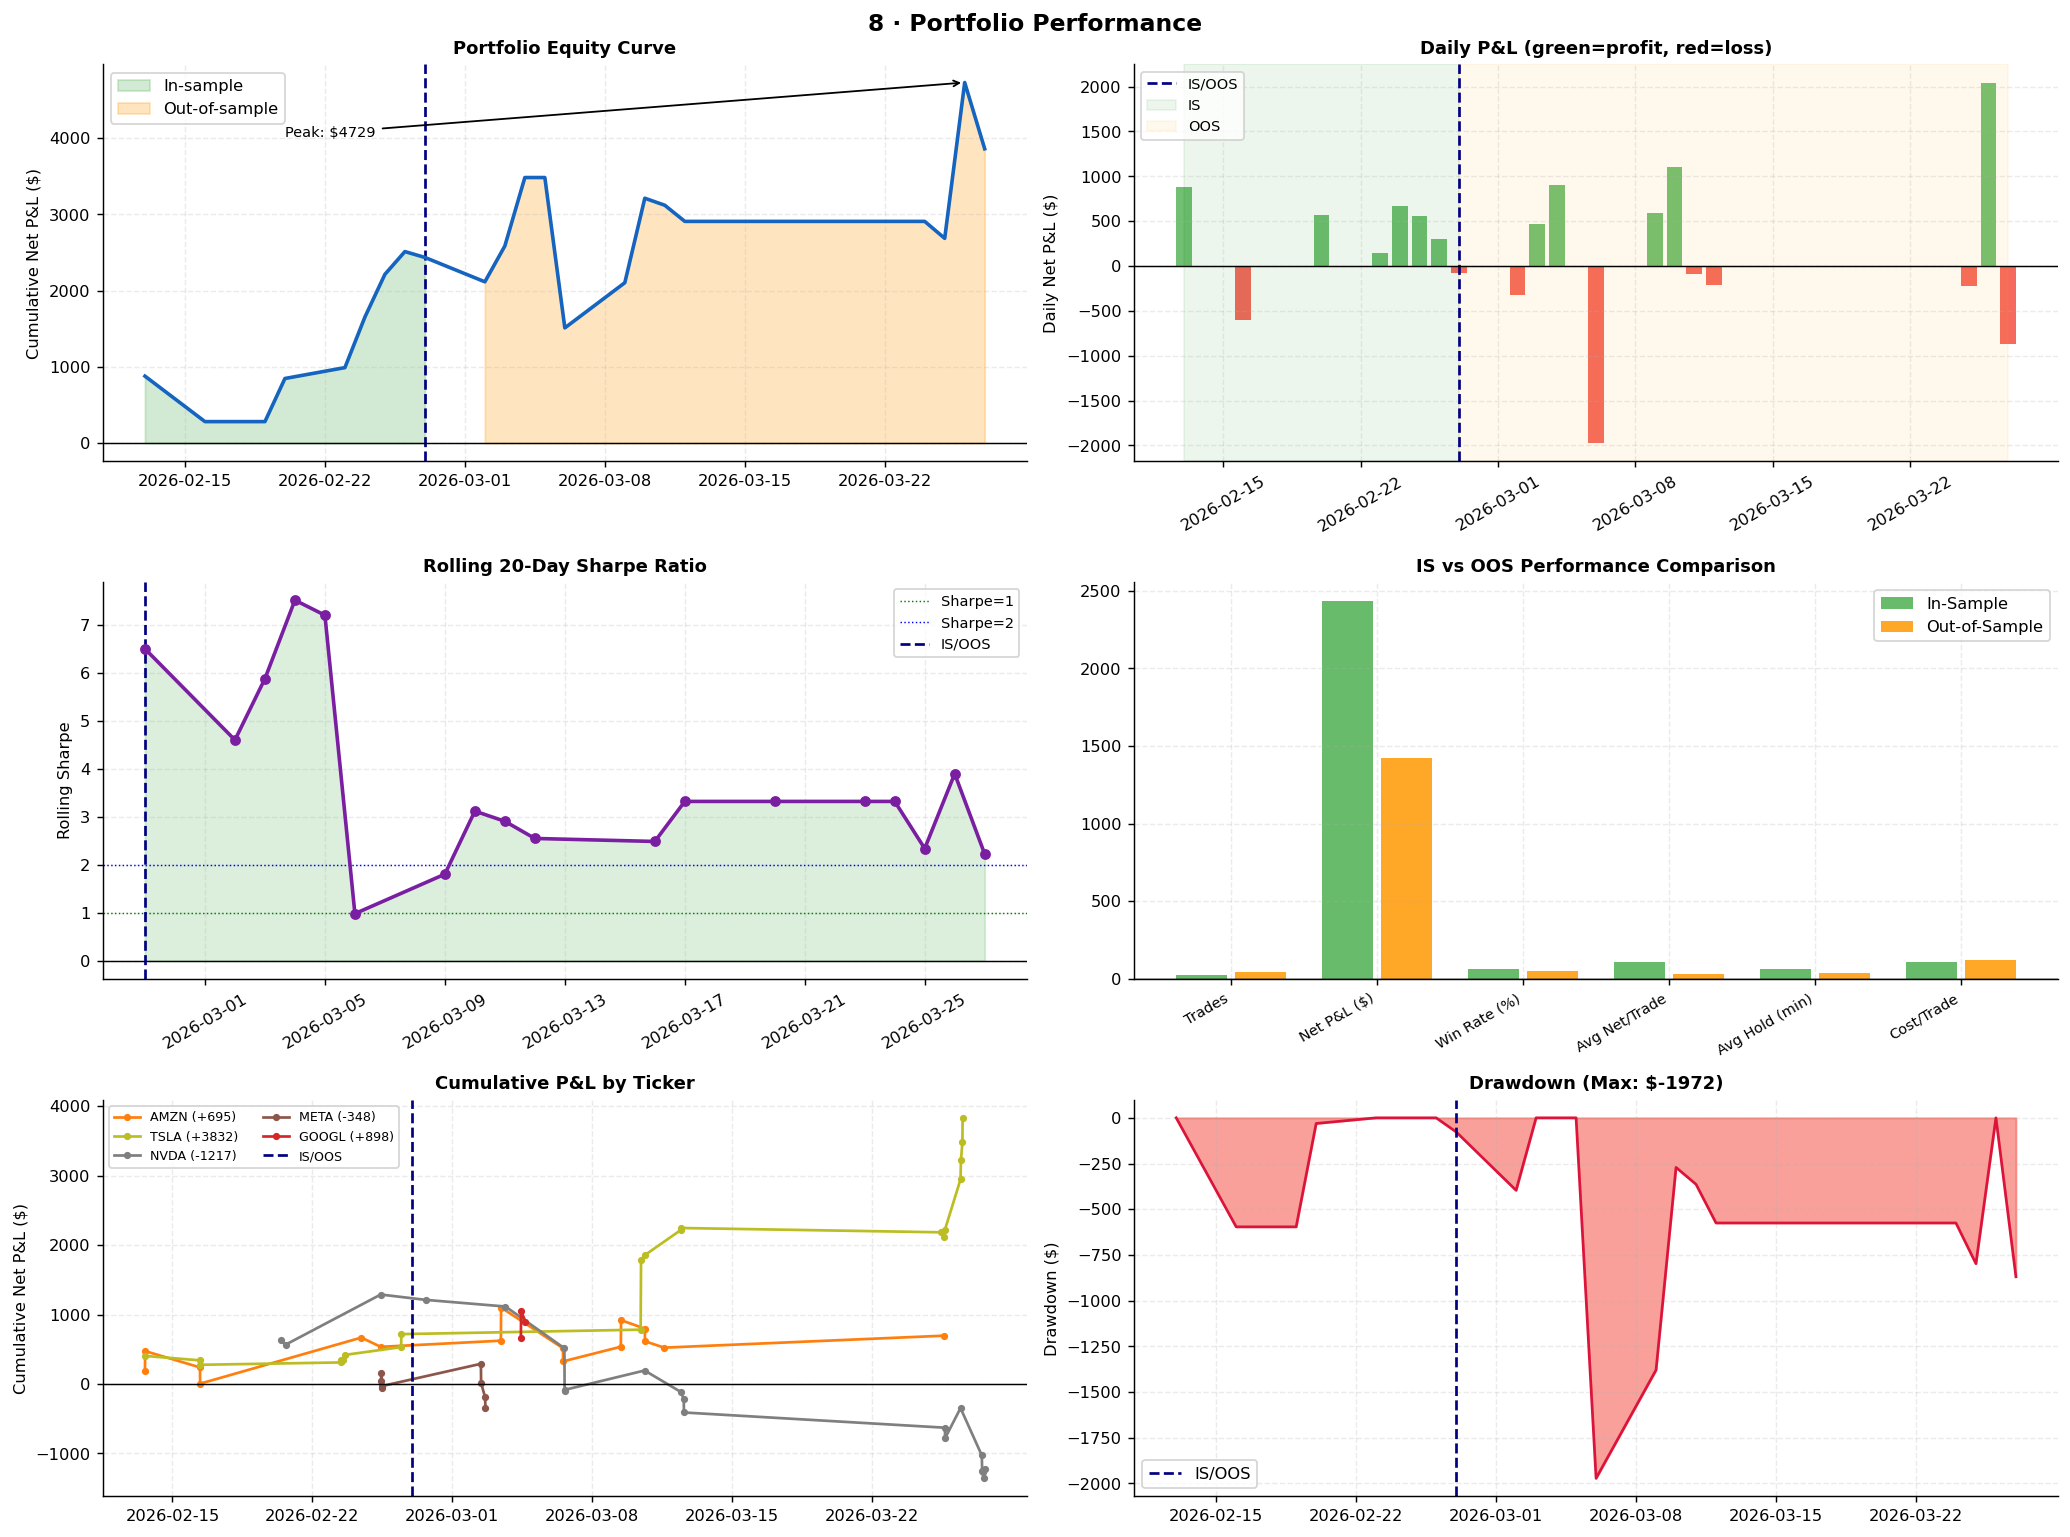

=== Overall Portfolio Statistics ===
Total net P&L       : $3,859.75
Ann. Sharpe (daily) : 3.104
Max Drawdown        : $-1,972.49
% days profitable   : 39.3%
Days with 0 P&L     : 9 / 28 (no signals fired)

=== IS vs OOS ===
IS  (23 trades): net=$ 2434.72  win%=65  avg_hold=65min  cost/trade=$108.97
OOS (45 trades): net=$ 1425.02  win%=49  avg_hold=37min  cost/trade=$121.61

⚠  portfolio_pnl in daily_pnl_combined.parquet is ~1e-7 (floating-point noise) — weighting bug in combine.py


In [24]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# ── 8a: Equity curve with IS/OOS shading ─────────────────────────────────
ax = axes[0,0]
dpnl_df_s = dpnl_df.sort_values('date')
cumsum = dpnl_df_s['total_pnl'].cumsum()
ax.fill_between(dpnl_df_s['date'], 0, cumsum,
                where=dpnl_df_s['date'] <= IS_END, alpha=0.25,
                color='#4CAF50', label='In-sample')
ax.fill_between(dpnl_df_s['date'], 0, cumsum,
                where=dpnl_df_s['date'] > IS_END, alpha=0.25,
                color='#FF9800', label='Out-of-sample')
ax.plot(dpnl_df_s['date'], cumsum, lw=2, color='#1565C0', zorder=5)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative Net P&L ($)'); ax.set_title('Portfolio Equity Curve')
ax.legend(fontsize=9)
peak = cumsum.max()
trough_idx = cumsum.idxmin()
ax.annotate(f'Peak: ${peak:.0f}', xy=(dpnl_df_s.loc[cumsum.idxmax(),'date'], peak),
            xytext=(dpnl_df_s['date'].iloc[5], peak*0.85),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8)

# ── 8b: Daily PnL bar chart ───────────────────────────────────────────────
ax = axes[0,1]
colors_d = ['#4CAF50' if v >= 0 else '#F44336' for v in dpnl_df_s['total_pnl']]
ax.bar(dpnl_df_s['date'], dpnl_df_s['total_pnl'], color=colors_d, 
       alpha=0.8, width=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Daily Net P&L ($)'); ax.set_title('Daily P&L (green=profit, red=loss)')
ax.tick_params(axis='x', rotation=30)
# Shade IS/OOS regions
ymin, ymax = ax.get_ylim()
ax.axvspan(dpnl_df_s['date'].min(), IS_END, alpha=0.07, color='green', label='IS')
ax.axvspan(IS_END, dpnl_df_s['date'].max(), alpha=0.07, color='orange', label='OOS')
ax.legend(fontsize=8)

# ── 8c: Rolling 20d Sharpe ────────────────────────────────────────────────
ax = axes[1,0]
rsh_valid = rsh_df.dropna()
ax.plot(rsh_valid['date'], rsh_valid['rolling_sharpe'], lw=2, color='#7B1FA2', 
        marker='o', ms=5, zorder=5)
ax.fill_between(rsh_valid['date'], 0, rsh_valid['rolling_sharpe'],
                where=rsh_valid['rolling_sharpe'] >= 0, alpha=0.2, color='#4CAF50')
ax.fill_between(rsh_valid['date'], 0, rsh_valid['rolling_sharpe'],
                where=rsh_valid['rolling_sharpe'] < 0, alpha=0.2, color='#F44336')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(1.0, color='green', lw=0.8, ls=':', label='Sharpe=1')
ax.axhline(2.0, color='blue',  lw=0.8, ls=':', label='Sharpe=2')
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Rolling Sharpe'); ax.set_title('Rolling 20-Day Sharpe Ratio')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

# ── 8d: IS vs OOS comparison bar chart ────────────────────────────────────
ax = axes[1,1]
is_trades  = tl_df[~tl_df['is_oos']]
oos_trades = tl_df[ tl_df['is_oos']]

def trade_stats(df):
    if len(df) == 0: return {}
    ret = df['pnl_net'] / 1_000_000
    sr  = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else 0
    return {
        'Trades': len(df), 'Net P&L ($)': df['pnl_net'].sum(),
        'Win Rate (%)': (df['pnl_net']>=0).mean()*100,
        'Avg Net/Trade': df['pnl_net'].mean(),
        'Avg Hold (min)': df['hold_min'].mean(),
        'Cost/Trade': df['cost'].mean(),
    }

is_s  = trade_stats(is_trades)
oos_s = trade_stats(oos_trades)

metrics = list(is_s.keys())
is_vals  = [is_s[m]  for m in metrics]
oos_vals = [oos_s[m] for m in metrics]

x_m = np.arange(len(metrics))
ax.bar(x_m - 0.2, is_vals,  width=0.35, label='In-Sample',    color='#4CAF50', alpha=0.85)
ax.bar(x_m + 0.2, oos_vals, width=0.35, label='Out-of-Sample', color='#FF9800', alpha=0.85)
ax.set_xticks(x_m)
ax.set_xticklabels(metrics, rotation=30, ha='right', fontsize=8)
ax.set_title('IS vs OOS Performance Comparison')
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.8)

# ── 8e: Cumulative P&L by ticker ─────────────────────────────────────────
ax = axes[2,0]
tl_df_s = tl_df.sort_values('entry_time')
for tkr in tl_df['ticker'].unique():
    sub = tl_df_s[tl_df_s['ticker']==tkr]
    cum = sub['pnl_net'].cumsum()
    ax.plot(sub['entry_time'], cum, lw=1.5, label=f'{tkr} ({cum.iloc[-1]:+.0f})',
            color=TICKER_CLR[tkr], marker='.')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Cumulative Net P&L ($)'); ax.set_title('Cumulative P&L by Ticker')
ax.legend(fontsize=7, ncol=2)

# ── 8f: Drawdown ─────────────────────────────────────────────────────────
ax = axes[2,1]
cumsum_r = dpnl_df_s['total_pnl'].cumsum()
running_max = cumsum_r.cummax()
drawdown = cumsum_r - running_max
ax.fill_between(dpnl_df_s['date'], drawdown, 0, color='#F44336', alpha=0.5)
ax.plot(dpnl_df_s['date'], drawdown, color='crimson', lw=1.5)
ax.axvline(IS_END, color='navy', lw=1.5, ls='--', label='IS/OOS')
ax.set_ylabel('Drawdown ($)'); ax.set_title(f'Drawdown (Max: ${drawdown.min():.0f})')
ax.legend(fontsize=9)

plt.suptitle('8 · Portfolio Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print('=== Overall Portfolio Statistics ===')
port_ret = dpnl_df_s['total_pnl'] / 1_000_000
port_sh  = port_ret.mean() / port_ret.std() * np.sqrt(252) if port_ret.std() > 0 else 0
print(f'Total net P&L       : ${dpnl_df_s["total_pnl"].sum():,.2f}')
print(f'Ann. Sharpe (daily) : {port_sh:.3f}')
print(f'Max Drawdown        : ${drawdown.min():,.2f}')
print(f'% days profitable   : {(dpnl_df_s["total_pnl"]>0).mean()*100:.1f}%')
print(f'Days with 0 P&L     : {(dpnl_df_s["total_pnl"]==0).sum()} / {len(dpnl_df_s)} (no signals fired)')
print()
print('=== IS vs OOS ===')
print(f'IS  ({len(is_trades):2d} trades): net=${is_trades["pnl_net"].sum():>8.2f}  win%={is_s["Win Rate (%)"]:.0f}  avg_hold={is_s["Avg Hold (min)"]:.0f}min  cost/trade=${is_s["Cost/Trade"]:.2f}')
print(f'OOS ({len(oos_trades):2d} trades): net=${oos_trades["pnl_net"].sum():>8.2f}  win%={oos_s["Win Rate (%)"]:.0f}  avg_hold={oos_s["Avg Hold (min)"]:.0f}min  cost/trade=${oos_s["Cost/Trade"]:.2f}')
print()
print('⚠  portfolio_pnl in daily_pnl_combined.parquet is ~1e-7 (floating-point noise) — weighting bug in combine.py')

## 9 · Risk Flags & Noteworthy Observations

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
RESULTS = ROOT / "results"
DATA = ROOT / "data"

def _safe_read(path):
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

def _sharpe(daily_ret):
    s = pd.Series(daily_ret).dropna()
    if len(s) < 5 or float(s.std()) < 1e-12:
        return 0.0
    return float((s.mean() / s.std()) * np.sqrt(252))

def _daily_pnl_stats(df, is_end):
    if df.empty:
        return {"is_sh": np.nan, "oos_sh": np.nan, "is_pnl": np.nan, "oos_pnl": np.nan}
    x = df.copy()
    x["date"] = pd.to_datetime(x["date"])
    total = x[[c for c in ["s1_pnl", "s4_pnl", "total_pnl"] if c in x.columns]].sum(axis=1)
    ret = total / 1_000_000
    is_mask = x["date"] <= pd.Timestamp(is_end)
    return {
        "is_sh": _sharpe(ret[is_mask]),
        "oos_sh": _sharpe(ret[~is_mask]),
        "is_pnl": float(total[is_mask].sum()),
        "oos_pnl": float(total[~is_mask].sum()),
    }

def _trade_stats(tr):
    if tr.empty:
        return {"n": 0, "wr": np.nan, "gross": np.nan, "net": np.nan, "cost": np.nan, "cost_share": np.nan}
    gross = float(tr["pnl_gross"].sum()) if "pnl_gross" in tr.columns else np.nan
    net = float(tr["pnl_net"].sum()) if "pnl_net" in tr.columns else np.nan
    cost = float(tr["cost"].sum()) if "cost" in tr.columns else np.nan
    wr = float((tr["pnl_net"] > 0).mean() * 100) if "pnl_net" in tr.columns else np.nan
    cost_share = (cost / abs(gross)) if gross not in (0, np.nan) else np.nan
    return {"n": len(tr), "wr": wr, "gross": gross, "net": net, "cost": cost, "cost_share": cost_share}

# Inputs
cfg = _safe_read(ROOT / "results" / "daily_pnl_net_slip25.parquet")
is_end = pd.Timestamp("2026-02-27")

dp10 = _safe_read(RESULTS / "daily_pnl_net_slip10.parquet")
dp25 = _safe_read(RESULTS / "daily_pnl_net_slip25.parquet")
dp50 = _safe_read(RESULTS / "daily_pnl_net_slip50.parquet")

tl10 = _safe_read(RESULTS / "trade_log_net_slip10.parquet")
tl25 = _safe_read(RESULTS / "trade_log_net_slip25.parquet")
tl50 = _safe_read(RESULTS / "trade_log_net_slip50.parquet")

s10 = _daily_pnl_stats(dp10, is_end)
s25 = _daily_pnl_stats(dp25, is_end)
s50 = _daily_pnl_stats(dp50, is_end)

t25 = _trade_stats(tl25)
t25_s1 = _trade_stats(tl25[tl25.get("strategy", "") == "S1"]) if not tl25.empty else _trade_stats(pd.DataFrame())

# Cost decomposition (slip25)
cost_cols = ["cost_entry_spread", "cost_exit_spread", "cost_slippage", "cost_fixed_fees", "cost_hedge_impact"]
if not tl25.empty and all(c in tl25.columns for c in cost_cols):
    csum = tl25[cost_cols].sum(numeric_only=True)
    ctot = float(tl25["cost"].sum()) if "cost" in tl25.columns else np.nan
else:
    csum = pd.Series(dtype=float)
    ctot = np.nan

# S4 participation
s4_n = int((tl25.get("strategy", pd.Series(dtype=str)) == "S4").sum()) if not tl25.empty else 0

# Scenario robustness
scenario_net = {
    "10%": float(dp10[[c for c in ["s1_pnl","s4_pnl","total_pnl"] if c in dp10.columns]].sum(axis=1).sum()) if not dp10.empty else np.nan,
    "25%": float(dp25[[c for c in ["s1_pnl","s4_pnl","total_pnl"] if c in dp25.columns]].sum(axis=1).sum()) if not dp25.empty else np.nan,
    "50%": float(dp50[[c for c in ["s1_pnl","s4_pnl","total_pnl"] if c in dp50.columns]].sum(axis=1).sum()) if not dp50.empty else np.nan,
}

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                NOTEWORTHY OBSERVATIONS — CURRENT RUN                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("1) WALK-FORWARD PROFILE (SENSITIVITY TO EXECUTION COSTS)")
print(f"   • 10% slip  : IS Sharpe={s10['is_sh']:.2f}, OOS Sharpe={s10['oos_sh']:.2f}, Total=${scenario_net['10%']:,.0f}")
print(f"   • 25% slip  : IS Sharpe={s25['is_sh']:.2f}, OOS Sharpe={s25['oos_sh']:.2f}, Total=${scenario_net['25%']:,.0f}")
print(f"   • 50% slip  : IS Sharpe={s50['is_sh']:.2f}, OOS Sharpe={s50['oos_sh']:.2f}, Total=${scenario_net['50%']:,.0f}")
print("   → Edge is highly cost-sensitive; conclusions should be based on realistic fill assumptions.\n")

print("2) CORE TRADE ECONOMICS (net 25% scenario)")
print(f"   • Trades={t25['n']}, Win Rate={t25['wr']:.1f}%")
print(f"   • Gross=${t25['gross']:,.0f}, Cost=${t25['cost']:,.0f}, Net=${t25['net']:,.0f}")
if np.isfinite(t25['cost_share']):
    print(f"   • Cost / |Gross| = {100*t25['cost_share']:.1f}%")
print("   → If cost consumes most of gross edge, strategy is execution-constrained.\n")

print("3) COST STACK DECOMPOSITION (net 25%)")
if len(csum) > 0 and np.isfinite(ctot) and ctot != 0:
    for k in cost_cols:
        v = float(csum.get(k, 0.0))
        print(f"   • {k:18s}: ${v:>10,.2f}  ({100*v/ctot:>5.1f}% of total cost)")
    print(f"   • {'total_cost':18s}: ${ctot:>10,.2f}")
else:
    print("   • Cost component columns not available in current trade log.")
print("   → Use this stack to decide whether to optimize fills, sizing, or trade frequency.\n")

print("4) STRATEGY CONCENTRATION")
print(f"   • S4 closed trades: {s4_n}")
print(f"   • S1 closed trades: {t25_s1['n']}")
if s4_n == 0:
    print("   • Entire realized P&L is effectively S1-driven in this run.")
print("   → Portfolio-level claims are weak until multiple independent sleeves contribute.\n")

print("5) TRADER TAKEAWAY")
print("   • Keep S1 but treat this as an execution problem first, signal problem second.")
print("   • Validate with robust slippage bands (10/25/50%), then tune filters on names where")
print("     cost-to-gross is lowest and fill quality is stable.")


╔══════════════════════════════════════════════════════════════════════════════╗
║                NOTEWORTHY OBSERVATIONS — CURRENT RUN                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

1) WALK-FORWARD PROFILE (SENSITIVITY TO EXECUTION COSTS)
   • 10% slip  : IS Sharpe=8.34, OOS Sharpe=1.57, Total=$7,719
   • 25% slip  : IS Sharpe=2.14, OOS Sharpe=-2.38, Total=$-3,059
   • 50% slip  : IS Sharpe=-1.38, OOS Sharpe=-4.56, Total=$-10,029
   → Edge is highly cost-sensitive; conclusions should be based on realistic fill assumptions.

2) CORE TRADE ECONOMICS (net 25% scenario)
   • Trades=68, Win Rate=42.6%
   • Gross=$11,839, Cost=$13,368, Net=$-1,530
   • Cost / |Gross| = 112.9%
   → If cost consumes most of gross edge, strategy is execution-constrained.

3) COST STACK DECOMPOSITION (net 25%)
   • cost_entry_spread : $  4,761.50  ( 35.6% of total cost)
   • cost_exit_spread  : $  3,484.75  ( 26.1% of total cost)
   • cost_slippage    